In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from alpsplot.figure import Figure
from alpsplot.colormap import tab20c_color, ting_color
# version 3 add 4 kinds of perturb rate

In [2]:
ting_color

{'red': '#DB3236',
 'red_carrot': '#E34638',
 'red_deep': '#C44C3F',
 'purple': '#593982',
 'green': '#429E46',
 'blue': '#6876AB',
 'blue_light': '#4885ED',
 'blue_grey': '#7396AE',
 'yellow': '#F7B52B',
 'yellow_deep': '#E7AD4C',
 'grey': '#989898'}

In [3]:
# total_dic = {}
# total_dic["r1llama"] = {}
# total_dic["r1llama"]["MathLogic"] = [0.136,0.091]
# total_dic["r1llama"]["SciEng"] = [0.276,0.161]
# total_dic["r1llama"]["Computing"] = [0.236,0.185]
# total_dic["r1llama"]["LifeSci"] = [0.194,0.326]
# total_dic["r1llama"]["Health"] = [0.160,0.538]
# total_dic["r1llama"]["BusinessEcon"] = [0.298,0.358]
# total_dic["r1llama"]["Society"] = [0.317,0.120]
# total_dic["r1llama"]["Humanities"] = [0.226,0.364]

# total_dic["r1qwen"] = {}
# total_dic["r1qwen"]["MathLogic"] = [0.073, 0.068]
# total_dic["r1qwen"]["SciEng"] = [0.096,0.180]
# total_dic["r1qwen"]["Computing"] = [0.070, 0.035]
# total_dic["r1qwen"]["LifeSci"] = []
# total_dic["r1qwen"]["Health"] = []
# total_dic["r1qwen"]["BusinessEcon"] = []
# total_dic["r1qwen"]["Society"] = []
# total_dic["r1qwen"]["Humanities"] = []

# total_dic["r1qwen3"] = {}
# total_dic["r1qwen3"]["MathLogic"] = [0.011, 0.033]
# total_dic["r1qwen3"]["SciEng"] = [0.008,0.216]
# total_dic["r1qwen3"]["Computing"] = [0.019, 0.248]
# total_dic["r1qwen3"]["LifeSci"] = []
# total_dic["r1qwen3"]["Health"] = []
# total_dic["r1qwen3"]["BusinessEcon"] = []
# total_dic["r1qwen3"]["Society"] = []
# total_dic["r1qwen3"]["Humanities"] = []


# total_dic["phi"] = {}
# total_dic["phi"]["MathLogic"] = [0.008,0.093]
# total_dic["phi"]["SciEng"] = [0.005, 0.094]
# total_dic["phi"]["Computing"] = [0.018,0.060]
# total_dic["phi"]["LifeSci"] = []
# total_dic["phi"]["Health"] = []
# total_dic["phi"]["BusinessEcon"] = []
# total_dic["phi"]["Society"] = []
# total_dic["phi"]["Humanities"] = []


# total_dic["qwen3"] = {}
# total_dic["qwen3"]["MathLogic"] = [0.003, 0.020]
# total_dic["qwen3"]["SciEng"] = [0.024,0.089]
# total_dic["qwen3"]["Computing"] = [0.002, 0.094]
# total_dic["qwen3"]["LifeSci"] = []
# total_dic["qwen3"]["Health"] = []
# total_dic["qwen3"]["BusinessEcon"] = []
# total_dic["qwen3"]["Society"] = []
# total_dic["qwen3"]["Humanities"] = []

In [4]:
'''
dic["model_name"] = dic2
dic2["group_name"] = [[1,0,1.0], 1.0, 1.0, [1,0,1.0]] # [FSR ICR] CoT_only CoT_mem_same 【memory, cot】
'''

'\ndic["model_name"] = dic2\ndic2["group_name"] = [[1,0,1.0], 1.0, 1.0, [1,0,1.0]] # [FSR ICR] CoT_only CoT_mem_same 【memory, cot】\n'

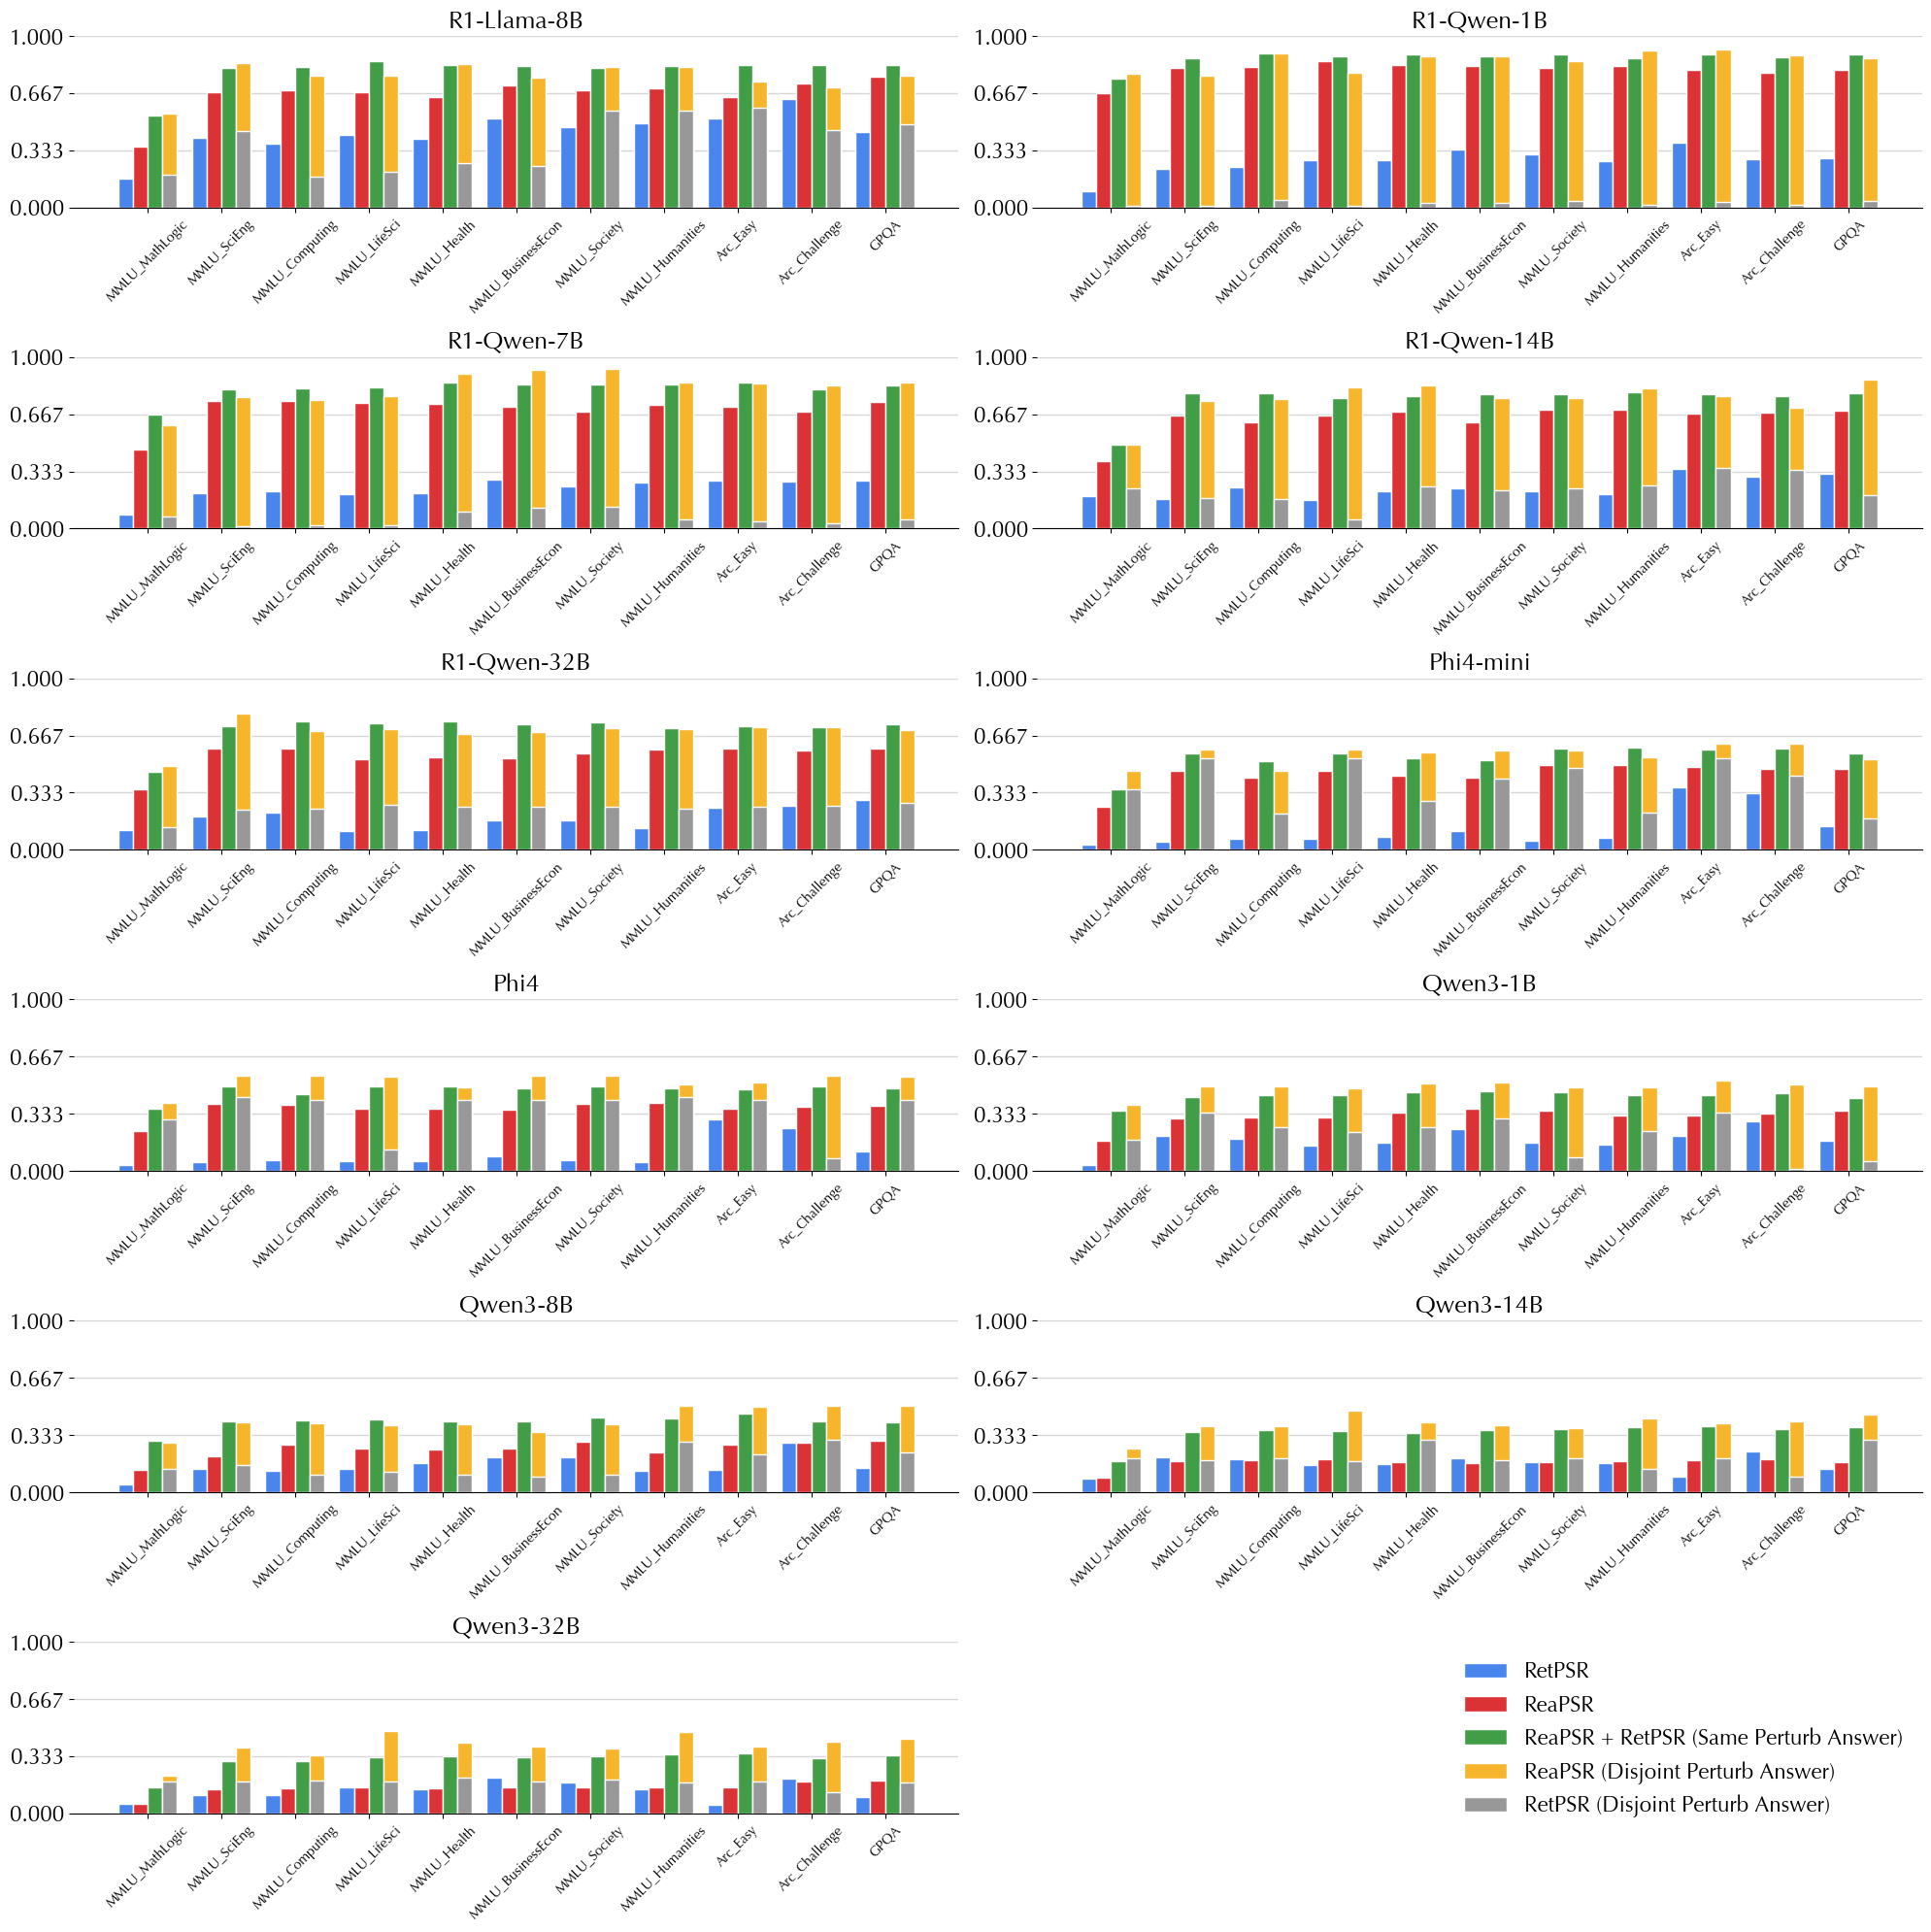

In [5]:
total_dic = {}
total_dic["r1llama"] = {}
total_dic["r1llama"]["MathLogic"] = [[0.076,0.091], 0.353, 0.536, [0.189, 0.358]]
total_dic["r1llama"]["SciEng"] = [[0.176,0.231], 0.674, 0.812, [0.445, 0.399]]
total_dic["r1llama"]["Computing"] = [[0.186,0.185], 0.685, 0.818, [0.181, 0.589]]
total_dic["r1llama"]["LifeSci"] = [[0.194,0.226], 0.672, 0.852, [0.209, 0.558]]
total_dic["r1llama"]["Health"] = [[0.160,0.238], 0.642, 0.832, [0.259, 0.578]]
total_dic["r1llama"]["BusinessEcon"] = [[0.258,0.258], 0.712, 0.822, [0.239, 0.515]]
total_dic["r1llama"]["Society"] = [[0.287,0.180], 0.683, 0.812, [0.563, 0.256]]
total_dic["r1llama"]["Humanities"] = [[0.226,0.264], 0.696, 0.823,[0.563, 0.256]]
total_dic["r1llama"]["arc_easy"] = [[0.291, 0.228], 0.642, 0.831, [0.583, 0.153]]
total_dic["r1llama"]["arc_challenge"] = [[0.327,0.303], 0.723, 0.832, [0.453, 0.244]]
total_dic["r1llama"]["gpqa"] = [[0.172,0.268], 0.762, 0.832, [0.483, 0.283]]



# total_dic["r1llama_rl"] = {}
# total_dic["r1llama_rl"]["MathLogic"] = [[0.058, 0.030]]
# total_dic["r1llama_rl"]["SciEng"] = [[0.153, 0.115]]
# total_dic["r1llama_rl"]["Computing"] = [[0.178, 0.132]]
# total_dic["r1llama_rl"]["LifeSci"] = [[0.173, 0.176]]
# total_dic["r1llama_rl"]["Health"] = [[0.139, 0.187]]
# total_dic["r1llama_rl"]["BusinessEcon"] = [[0.240, 0.194]]
# total_dic["r1llama_rl"]["Society"] = [[0.262, 0.140]]
# total_dic["r1llama_rl"]["Humanities"] = [[0.204, 0.201]]


total_dic["r1qwen"] = {}
total_dic["r1qwen"]["MathLogic"] = [[0.033, 0.048], 0.459, 0.665, [0.073, 0.53]]
total_dic["r1qwen"]["SciEng"] = [[0.096,0.110], 0.742, 0.812, [0.014, 0.75]]
total_dic["r1qwen"]["Computing"] = [[0.120, 0.095], 0.746, 0.818, [0.017, 0.73]]
total_dic["r1qwen"]["LifeSci"] = [[0.112,0.086], 0.734, 0.822, [0.019, 0.753]]
total_dic["r1qwen"]["Health"] = [[0.120,0.088], 0.725, 0.852, [0.10, 0.803]]
total_dic["r1qwen"]["BusinessEcon"] = [[0.158,0.128], 0.712, 0.842,[0.12, 0.804]]
total_dic["r1qwen"]["Society"] = [[0.137,0.110], 0.683, 0.842, [0.13, 0.803]]
total_dic["r1qwen"]["Humanities"] = [[0.136,0.134], 0.723,0.842, [0.052, 0.801]]
total_dic["r1qwen"]["arc_easy"] = [[0.083, 0.198], 0.712, 0.853, [0.043, 0.805]]
total_dic["r1qwen"]["arc_challenge"] = [[0.093,0.183], 0.683, 0.813, [0.032, 0.803]]
total_dic["r1qwen"]["gpqa"] = [[0.111,0.168], 0.739, 0.832, [0.051, 0.802]]

# total_dic["r1qwen_rl"] = {}
# total_dic["r1qwen_rl"]["MathLogic"] = [[0.023, 0.026]]   
# total_dic["r1qwen_rl"]["SciEng"] = [[0.085, 0.077]]      
# total_dic["r1qwen_rl"]["Computing"] = [[0.115, 0.070]]  
# total_dic["r1qwen_rl"]["LifeSci"] = [[0.104, 0.062]]       
# total_dic["r1qwen_rl"]["Health"] = [[0.114, 0.068]]       
# total_dic["r1qwen_rl"]["BusinessEcon"] = [[0.148, 0.093]]  
# total_dic["r1qwen_rl"]["Society"] = [[0.127, 0.079]]      
# total_dic["r1qwen_rl"]["Humanities"] = [[0.126, 0.101]]    


total_dic["r1qwen1b"] = {}
total_dic["r1qwen1b"]["MathLogic"] = [[0.053, 0.044], 0.665, 0.752, [0.012, 0.765]]
total_dic["r1qwen1b"]["SciEng"] = [[0.197,0.026], 0.812, 0.872, [0.012, 0.755]]
total_dic["r1qwen1b"]["Computing"] = [[0.193, 0.042], 0.818, 0.898, [0.045, 0.855]]
total_dic["r1qwen1b"]["LifeSci"] = [[0.212,0.066], 0.852, 0.882, [0.012, 0.775]]
total_dic["r1qwen1b"]["Health"] = [[0.210,0.068], 0.832, 0.892, [0.025, 0.855]]
total_dic["r1qwen1b"]["BusinessEcon"] = [[0.238,0.102], 0.822, 0.882, [0.025, 0.855]]
total_dic["r1qwen1b"]["Society"] = [[0.207,0.100], 0.812, 0.892, [0.035, 0.815]]
total_dic["r1qwen1b"]["Humanities"] = [[0.186,0.084], 0.822, 0.872, [0.015, 0.902]]
total_dic["r1qwen1b"]["arc_easy"] = [[0.131, 0.248], 0.802, 0.893, [0.034, 0.885]]
total_dic["r1qwen1b"]["arc_challenge"] = [[0.137,0.143], 0.783, 0.878, [0.015, 0.874]]
total_dic["r1qwen1b"]["gpqa"] = [[0.132,0.156], 0.804, 0.892, [0.035, 0.835]]

total_dic["r1qwen14b"] = {}
total_dic["r1qwen14b"]["MathLogic"] = [[0.046, 0.146], 0.392, 0.492, [0.234, 0.256]]
total_dic["r1qwen14b"]["SciEng"] = [[0.020,0.153], 0.662, 0.792,[0.177, 0.567]]
total_dic["r1qwen14b"]["Computing"] = [[0.067, 0.171], 0.618, 0.788, [0.175, 0.583]]
total_dic["r1qwen14b"]["LifeSci"] = [[0.062,0.106], 0.662, 0.762, [0.056, 0.767]]
total_dic["r1qwen14b"]["Health"] = [[0.061,0.158], 0.682,0.773,[0.245, 0.587]]
total_dic["r1qwen14b"]["BusinessEcon"] = [[0.078,0.158], 0.622,0.782, [0.225, 0.536]]
total_dic["r1qwen14b"]["Society"] = [[0.067,0.152], 0.692,0.782, [0.236, 0.526]]
total_dic["r1qwen14b"]["Humanities"] = [[0.066,0.134], 0.692,0.795, [0.253, 0.562]]
total_dic["r1qwen14b"]["arc_easy"] = [[0.061, 0.288], 0.672, 0.783, [0.352, 0.421]]
total_dic["r1qwen14b"]["arc_challenge"] = [[0.071,0.233], 0.675, 0.773, [0.342, 0.362]]
total_dic["r1qwen14b"]["gpqa"] = [[0.094,0.226], 0.685, 0.791, [0.197, 0.672]]

total_dic["r1qwen32b"] = {}
total_dic["r1qwen32b"]["MathLogic"] = [[0.017, 0.096], 0.352, 0.452, [0.133, 0.353]]
total_dic["r1qwen32b"]["SciEng"] = [[0.013,0.179], 0.592, 0.722, [0.232, 0.563]]
total_dic["r1qwen32b"]["Computing"] = [[0.028, 0.189], 0.588, 0.748, [0.241, 0.452]]
total_dic["r1qwen32b"]["LifeSci"] = [[0.021,0.089], 0.528, 0.738, [0.261, 0.442]]
total_dic["r1qwen32b"]["Health"] = [[0.025,0.089], 0.538, 0.748, [0.251, 0.425]]
total_dic["r1qwen32b"]["BusinessEcon"] = [[0.031,0.139], 0.532, 0.732, [0.251, 0.435]]
total_dic["r1qwen32b"]["Society"] = [[0.032,0.139], 0.562, 0.742, [0.251, 0.461]]
total_dic["r1qwen32b"]["Humanities"] = [[0.030,0.099], 0.582, 0.712, [0.240, 0.461]]
total_dic["r1qwen32b"]["arc_easy"] = [[0.046, 0.198], 0.593, 0.723, [0.253, 0.462]]
total_dic["r1qwen32b"]["arc_challenge"] = [[0.053,0.203], 0.581, 0.713, [0.255, 0.462]]
total_dic["r1qwen32b"]["gpqa"] = [[0.072,0.218], 0.589, 0.734, [0.274, 0.425]]

# total_dic["r1qwen3"] = {}
# total_dic["r1qwen3"]["MathLogic"] = [0.011, 0.033]
# total_dic["r1qwen3"]["SciEng"] = [0.038,0.166]
# total_dic["r1qwen3"]["Computing"] = [0.049, 0.148]
# total_dic["r1qwen3"]["LifeSci"] = [0.051, 0.158]
# total_dic["r1qwen3"]["Health"] = [0.058, 0.159]
# total_dic["r1qwen3"]["BusinessEcon"] = [0.051, 0.198]
# total_dic["r1qwen3"]["Society"] = [0.049, 0.113]
# total_dic["r1qwen3"]["Humanities"] = [0.048, 0.143]


total_dic["phi"] = {}
total_dic["phi"]["MathLogic"] = [[0.008,0.023], 0.252, 0.352, [0.353, 0.105]]
total_dic["phi"]["SciEng"] = [[0.015, 0.034], 0.462, 0.562, [0.532, 0.054]]
total_dic["phi"]["Computing"] = [[0.018,0.046], 0.418, 0.518, [0.213, 0.245]]
total_dic["phi"]["LifeSci"] = [[0.028,0.034], 0.462, 0.562, [0.532, 0.054]]
total_dic["phi"]["Health"] = [[0.032,0.043], 0.432, 0.532, [0.285, 0.285]]
total_dic["phi"]["BusinessEcon"] = [[0.038,0.071], 0.422, 0.522, [0.415, 0.165]]
total_dic["phi"]["Society"] = [[0.022,0.032], 0.492, 0.592, [0.475, 0.105]]
total_dic["phi"]["Humanities"] = [[0.028,0.041], 0.492, 0.594, [0.215, 0.325]]
total_dic["phi"]["arc_easy"] = [[0.201, 0.161], 0.483, 0.583, [0.533, 0.085]]
total_dic["phi"]["arc_challenge"] = [[0.157,0.171], 0.473, 0.593, [0.433, 0.185]]
total_dic["phi"]["gpqa"] = [[0.038,0.102], 0.472, 0.561, [0.185, 0.345]]

total_dic["phibig"] = {}
total_dic["phibig"]["MathLogic"] = [[0.004,0.033], 0.232, 0.362, [0.303, 0.095]]
total_dic["phibig"]["SciEng"] = [[0.010, 0.044], 0.392, 0.492, [0.433, 0.124]]
total_dic["phibig"]["Computing"] = [[0.011,0.052], 0.388, 0.448, [0.413, 0.144]]
total_dic["phibig"]["LifeSci"] = [[0.014,0.041], 0.362, 0.492,[0.123, 0.424]]
total_dic["phibig"]["Health"] = [[0.019,0.041], 0.362, 0.492, [0.413, 0.074]]
total_dic["phibig"]["BusinessEcon"] = [[0.019,0.069], 0.36, 0.482, [0.413, 0.144]]
total_dic["phibig"]["Society"] = [[0.017,0.048], 0.392, 0.492, [0.413, 0.144]]
total_dic["phibig"]["Humanities"] = [[0.013,0.039], 0.395,0.483, [0.433,0.072]]
total_dic["phibig"]["arc_easy"] = [[0.167, 0.131], 0.365, 0.477, [0.413, 0.105]]
total_dic["phibig"]["arc_challenge"] = [[0.117,0.131], 0.373, 0.494, [0.072, 0.485]]
total_dic["phibig"]["gpqa"] = [[0.021,0.092], 0.381, 0.480, [0.415, 0.134]]


total_dic["qwen3"] = {}
total_dic["qwen3"]["MathLogic"] = [[0.003, 0.040], 0.132, 0.302,[0.133, 0.158]]
total_dic["qwen3"]["SciEng"] = [[0.024,0.109], 0.209,0.414, [0.156, 0.253]]
total_dic["qwen3"]["Computing"] = [[0.012, 0.114], 0.277,0.417, [0.10, 0.30]]
total_dic["qwen3"]["LifeSci"] = [[0.002, 0.134], 0.256,0.426, [0.116, 0.273]]
total_dic["qwen3"]["Health"] = [[0.017, 0.154], 0.251,0.411, [0.103, 0.293]]
total_dic["qwen3"]["BusinessEcon"] = [[0.021, 0.184], 0.255,0.415, [0.093, 0.258]]
total_dic["qwen3"]["Society"] = [[0.019, 0.184], 0.295,0.435, [0.103, 0.293]]
total_dic["qwen3"]["Humanities"] = [[0.013, 0.111], 0.231, 0.428, [0.293, 0.213]]
total_dic["qwen3"]["arc_easy"] = [[0.067, 0.061], 0.279, 0.457, [0.223, 0.273]]
total_dic["qwen3"]["arc_challenge"] = [[0.126,0.162], 0.289, 0.413, [0.303, 0.203]]
total_dic["qwen3"]["gpqa"] = [[0.091,0.051], 0.299, 0.410, [0.233, 0.273]]


# total_dic["qwen34b"] = {}
# total_dic["qwen34b"]["MathLogic"] = [[0.008, 0.021], 0.154]
# total_dic["qwen34b"]["SciEng"] = [[0.032,0.083], 0.258]
# total_dic["qwen34b"]["Computing"] = [[0.036, 0.101], 0.269]
# total_dic["qwen34b"]["LifeSci"] = [[0.008, 0.118], 0.285]
# total_dic["qwen34b"]["Health"] = [[0.020, 0.121], 0.28 ]
# total_dic["qwen34b"]["BusinessEcon"] = [[0.030, 0.194], 0.274]
# total_dic["qwen34b"]["Society"] = [[0.018, 0.165], 0.295]
# total_dic["qwen34b"]["Humanities"] = [[0.017, 0.103], 0.301]
# total_dic["qwen34b"]["arc_easy"] = [[0.082, 0.061], 0.922]
# total_dic["qwen34b"]["arc_challenge"] = [[0.146,0.172], 0.942]
# total_dic["qwen34b"]["gpqa"] = [[0.111,0.041], 0.892]

total_dic["qwen31b"] = {}
total_dic["qwen31b"]["MathLogic"] = [[0.014, 0.021], 0.179, 0.353, [0.183, 0.205]]
total_dic["qwen31b"]["SciEng"] = [[0.052,0.150], 0.309,0.432, [0.343, 0.153]]
total_dic["qwen31b"]["Computing"] = [[0.056, 0.132], 0.314,0.441, [0.253, 0.243]]
total_dic["qwen31b"]["LifeSci"] = [[0.012, 0.134], 0.313,0.443, [0.225, 0.258]]
total_dic["qwen31b"]["Health"] = [[0.027, 0.136], 0.343,0.461, [0.258, 0.251]]
total_dic["qwen31b"]["BusinessEcon"] = [[0.032, 0.214], 0.365,0.465, [0.307, 0.208]]
total_dic["qwen31b"]["Society"] = [[0.030, 0.137], 0.353,0.462, [0.078, 0.408]]
total_dic["qwen31b"]["Humanities"] = [[0.021, 0.131], 0.321, 0.441, [0.232, 0.256]]
total_dic["qwen31b"]["arc_easy"] = [[0.123, 0.081], 0.323, 0.443, [0.341, 0.187]]
total_dic["qwen31b"]["arc_challenge"] = [[0.156,0.131], 0.333, 0.453, [0.013, 0.494]]
total_dic["qwen31b"]["gpqa"] = [[0.123,0.051], 0.353, 0.423, [0.056, 0.435]]


total_dic["qwen314b"] = {}
total_dic["qwen314b"]["MathLogic"] = [[0.002, 0.076], 0.083, 0.183, [0.198, 0.054]]
total_dic["qwen314b"]["SciEng"] = [[0.014,0.189], 0.182,0.352, [0.188, 0.194]]
total_dic["qwen314b"]["Computing"] = [[0.008, 0.184], 0.186,0.362, [0.199,0.187]]
total_dic["qwen314b"]["LifeSci"] = [[0.002, 0.154], 0.195,0.357, [0.183, 0.294]]
total_dic["qwen314b"]["Health"] = [[0.009, 0.154], 0.175,0.345, [0.304, 0.103]]
total_dic["qwen314b"]["BusinessEcon"] = [[0.015, 0.184], 0.167,0.362, [0.188, 0.204]]
total_dic["qwen314b"]["Society"] = [[0.010, 0.164], 0.175,0.365, [0.198, 0.174]]
total_dic["qwen314b"]["Humanities"] = [[0.006, 0.166], 0.179, 0.379, [0.138, 0.294]]
total_dic["qwen314b"]["arc_easy"] = [[0.037, 0.051], 0.184, 0.383, [0.198, 0.204]]
total_dic["qwen314b"]["arc_challenge"] = [[0.086,0.152], 0.194, 0.367, [0.088, 0.324]]
total_dic["qwen314b"]["gpqa"] = [[0.061,0.072], 0.177, 0.377, [0.304, 0.147]]

total_dic["qwen332b"] = {}
total_dic["qwen332b"]["MathLogic"] = [[0.002, 0.056], 0.053, 0.153, [0.187, 0.032]]
total_dic["qwen332b"]["SciEng"] = [[0.008,0.097], 0.143,0.302, [0.188, 0.194]]
total_dic["qwen332b"]["Computing"] = [[0.005, 0.099], 0.146, 0.306, [0.194, 0.142]]
total_dic["qwen332b"]["LifeSci"] = [[0.002, 0.149], 0.154, 0.329, [0.187, 0.294]]
total_dic["qwen332b"]["Health"] = [[0.004, 0.139], 0.145, 0.331, [0.207, 0.204]]
total_dic["qwen332b"]["BusinessEcon"] = [[0.010, 0.199], 0.154,0.329, [0.188, 0.203]]
total_dic["qwen332b"]["Society"] = [[0.002, 0.179], 0.153,0.332, [0.198, 0.182]]
total_dic["qwen332b"]["Humanities"] = [[0.004, 0.139], 0.153, 0.342, [0.178, 0.294]]
total_dic["qwen332b"]["arc_easy"] = [[0.021, 0.031], 0.154, 0.352, [0.188, 0.204]]
total_dic["qwen332b"]["arc_challenge"] = [[0.071,0.132], 0.184, 0.322, [0.126, 0.294]]
total_dic["qwen332b"]["gpqa"] = [[0.042,0.051], 0.194, 0.337, [0.179, 0.254]]

model_name_list = ["r1llama", "r1qwen1b","r1qwen", "r1qwen14b", "r1qwen32b", "phi", "phibig", "qwen31b","qwen3",  "qwen314b", "qwen332b"]
model_label_list = ["R1-Llama-8B", "R1-Qwen-1B","R1-Qwen-7B", "R1-Qwen-14B", "R1-Qwen-32B", "Phi4-mini", "Phi4", "Qwen3-1B","Qwen3-8B", "Qwen3-14B", "Qwen3-32B"]

group_name_list = ['MathLogic', 'SciEng', 'Computing', 'LifeSci', 'Health', 'BusinessEcon', 'Society', 'Humanities', 'arc_easy', 'arc_challenge', 'gpqa']
group_label_list = ['MMLU_MathLogic', 'MMLU_SciEng', 'MMLU_Computing', 'MMLU_LifeSci', 'MMLU_Health', 'MMLU_BusinessEcon', 'MMLU_Society', 'MMLU_Humanities', 'Arc_Easy', 'Arc_Challenge', 'GPQA']
bar_color_list = [ting_color["blue_light"], ting_color["red"], ting_color["green"], ting_color['yellow'], ting_color["grey"], 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta']
bar_label_list = ['RetPSR','ReaPSR','ReaPSR + RetPSR (Same Perturb Answer)', 'ReaPSR (Disjoint Perturb Answer)', 'RetPSR (Disjoint Perturb Answer)', 'ReaPSR + RetPSR (Disjoint Perturb Answer)']
fig_all, axes = plt.subplots(6, 2, figsize=(20,20))
fig_all.subplots_adjust(wspace=0.4, hspace=1) 
count = 0
width = 0.2
x = np.arange(len(group_name_list))
x1 = x - width/2 * 3
x2 = x - width/2
x3 = x + width/2
x4 = x + width/2 * 3
for i in range(7):
    for j in range(2):
        if count >=11:
            break
        model_name = model_name_list[count]
        model_label = model_label_list[count]
        fig = Figure(name = f'{model_name}', figsize=(3, 3), ax=axes[i, j])
        fig.set_axis_lim("x", piece = len(group_name_list) - 1, lim = (0, len(group_name_list) - 1), labels = group_label_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
        fig.set_axis_lim("y", lim = (0, 1), piece = 3)
        x = np.arange(len(group_name_list))
        FSR = []
        ICR = []
        FSR_ICR = []
        CCR = [] # cot cue rate
        CMCR = [] # cot memory consistent perturb rate
        CMICR_back = [] # cot memory inconsistent perturb rate
        CMICR_forward = [] # cot memory inconsistent perturb rate
        CMICR_top = []
        for group in group_name_list:
            temp_list = total_dic[model_name][group][0]
            if len(temp_list) != 2:
                temp_list = [0, 0]
            FSR.append(temp_list[0])
            ICR.append(temp_list[1])
            FSR_ICR.append(temp_list[0] + temp_list[1])
            # print(total_dic[model_name][group])
            CCR.append(total_dic[model_name][group][1])
            CMCR.append(total_dic[model_name][group][2])
            # CMICR.append(total_dic[model_name][group][3])
            temp_list2 = total_dic[model_name][group][3]
            CMICR_back.append(temp_list2[0] + temp_list2[1])
            CMICR_forward.append(temp_list2[0])
            CMICR_top.append(temp_list2[1])
        total_dic[model_name]["FSR"] = sum(FSR) / len(FSR)
        total_dic[model_name]["ICR"] = sum(ICR) / len(ICR)
        total_dic[model_name]["CCR"] = sum(CCR) / len(CCR)
        total_dic[model_name]["FSR_ICR"] = sum(FSR_ICR) / len(FSR_ICR)
        total_dic[model_name]["is_same"] = sum(CMCR) / len(CMCR)
        total_dic[model_name]["not_same_back"] =  sum(CMICR_back) / len(CMICR_back)
        total_dic[model_name]["not_same_forward"] = sum(CMICR_forward) / len(CMICR_forward)
        total_dic[model_name]["not_same_top"] = sum(CMICR_top) / len(CMICR_top)
        bar1 = fig.bar(x1, FSR_ICR, width = width, label=bar_label_list[0], color = bar_color_list[0], align= 'center')
        bar2 = fig.bar(x2, CCR, width = width, label=bar_label_list[1], color = bar_color_list[1], align= 'center')
        bar3 = fig.bar(x3, CMCR, width = width, label=bar_label_list[2], color = bar_color_list[2], align= 'center')
        fig.set_title(model_label)
        bar4 = fig.bar(x4, CMICR_back, width = width, label=bar_label_list[3], color = bar_color_list[3], align= 'center')
        bar5 = fig.bar(x4, CMICR_forward, width = width, label=bar_label_list[4], color = bar_color_list[4], align= 'center')
        # get the legend
        handles, labels = fig.ax.get_legend_handles_labels()
        # fig.ax.legend(handles[::-1], labels[::-1], loc='upper left')

        # fig.ax.tick_params(axis = 'x', rotation = 45)
        count += 1
fig = Figure(name = f'{model_name}', figsize=(3, 3), ax=axes[5, 1])
fig.set_legend(handles, labels)
# hide the axis
fig.ax.axis('off')
plt.tight_layout()
plt.show()

path = "output/all_model_group.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

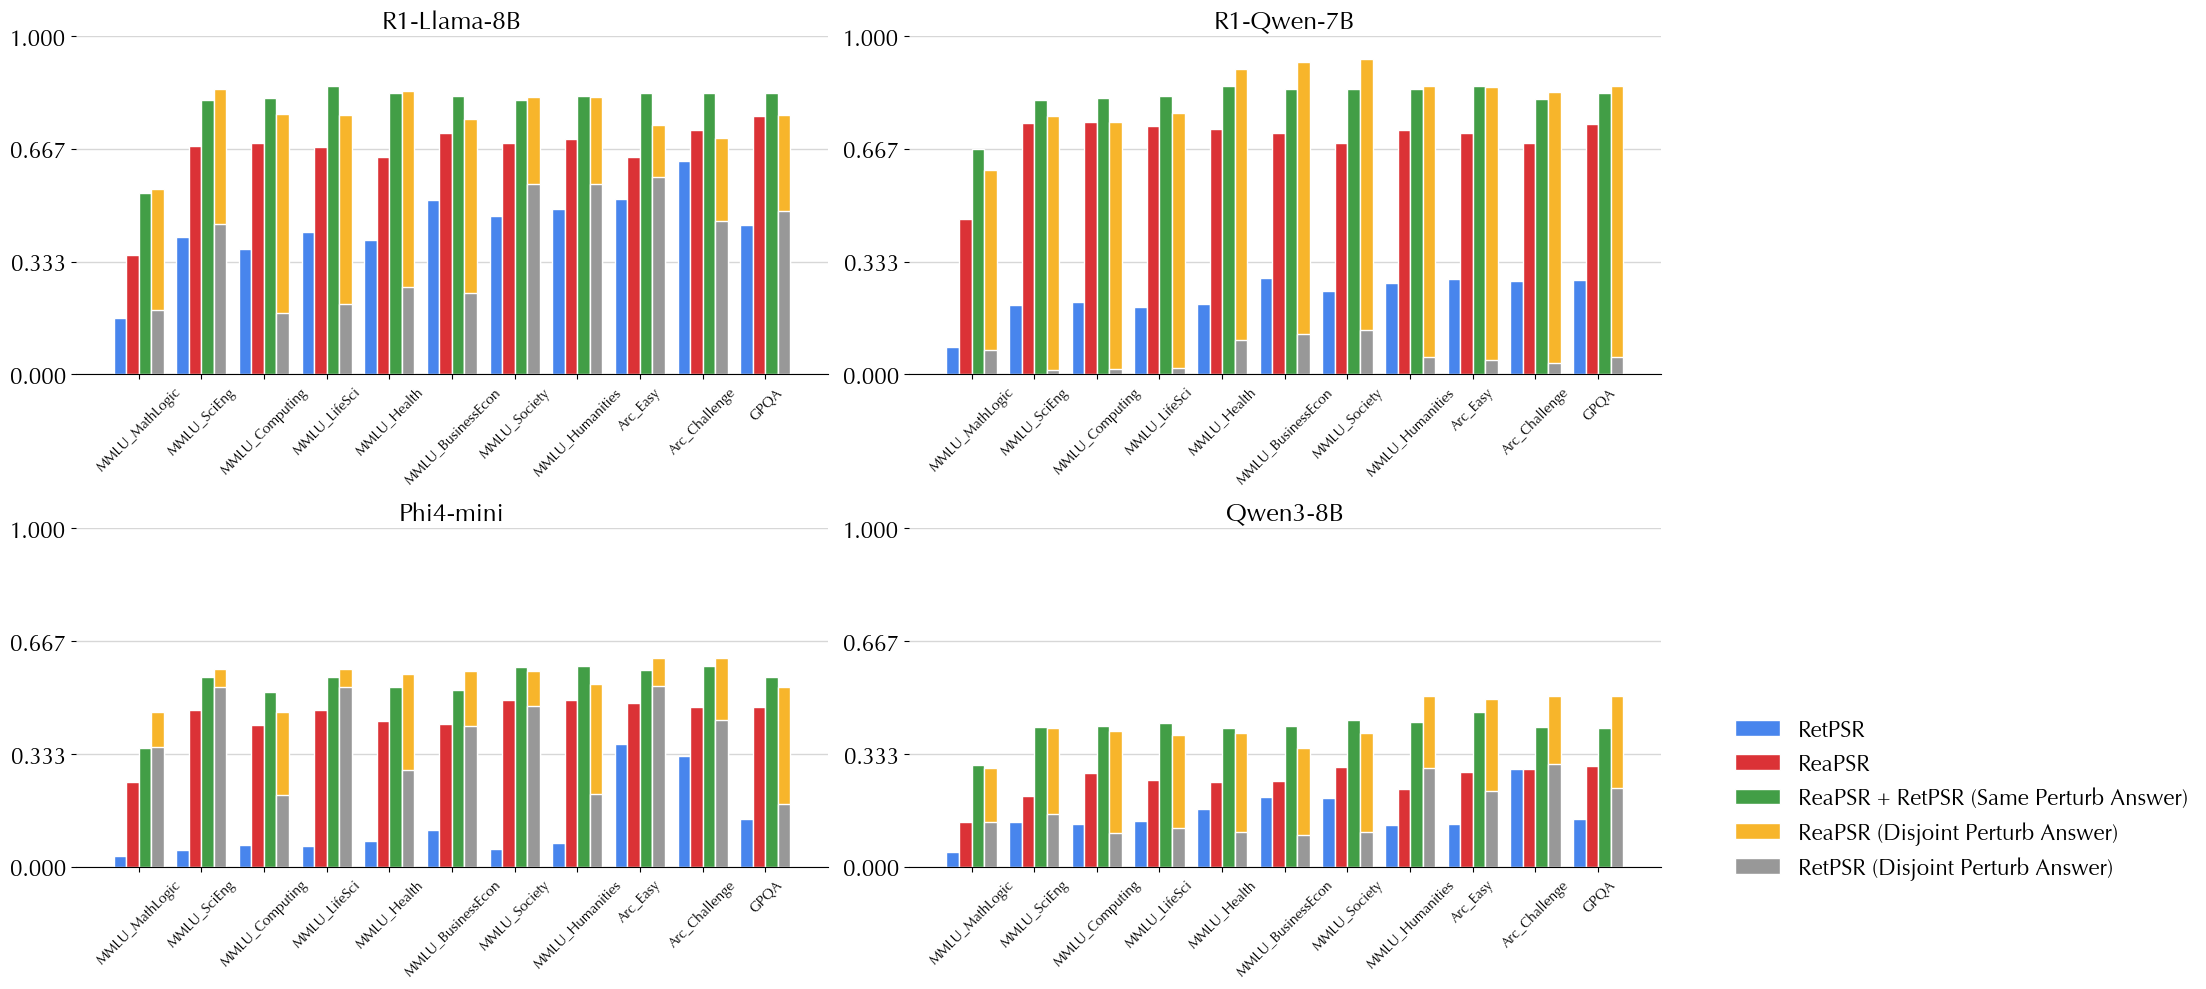

In [6]:
model_name_list_select = ["r1llama","r1qwen", "phi","qwen3"]
model_label_list_select = ["R1-Llama-8B","R1-Qwen-7B", "Phi4-mini","Qwen3-8B"]

group_name_list = ['MathLogic', 'SciEng', 'Computing', 'LifeSci', 'Health', 'BusinessEcon', 'Society', 'Humanities', 'arc_easy', 'arc_challenge', 'gpqa']
group_label_list = ['MMLU_MathLogic', 'MMLU_SciEng', 'MMLU_Computing', 'MMLU_LifeSci', 'MMLU_Health', 'MMLU_BusinessEcon', 'MMLU_Society', 'MMLU_Humanities', 'Arc_Easy', 'Arc_Challenge', 'GPQA']
# bar_color_list = [ting_color["blue_light"], ting_color["red"], ting_color["green"], ting_color['yellow'], ting_color["grey"], 'orange', 'brown', 'pink', 'gray', 'cyan', 'magenta']
# bar_label_list = ['ReaPSR', 'RetPSR', 'ReaPSR + RetPSR (Same Perturb Answer)', 'ReaPSR (Disjoint Perturb Answer)', 'RetPSR (Disjoint Perturb Answer)']
fig_all, axes = plt.subplots(2, 2, figsize=(22,10))
fig_all.subplots_adjust(wspace=0.4, hspace=1) 
count = 0
width = 0.2
x = np.arange(len(group_name_list))
x1 = x - width/2 * 3
x2 = x - width/2
x3 = x + width/2
x4 = x + width/2 * 3
for i in range(2):
    for j in range(2):
        if count >=4:
            break
        model_name = model_name_list_select[count]
        model_label = model_label_list_select[count]
        fig = Figure(name = f'{model_name}', figsize=(3, 3), ax=axes[i, j])
        fig.set_axis_lim("x", piece = len(group_name_list) - 1, lim = (0, len(group_name_list) - 1), labels = group_label_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
        fig.set_axis_lim("y", lim = (0, 1), piece = 3)
        x = np.arange(len(group_name_list))
        FSR = []
        ICR = []
        FSR_ICR = []
        CCR = [] # cot cue rate
        CMCR = [] # cot memory consistent perturb rate
        CMICR_back = [] # cot memory inconsistent perturb rate
        CMICR_forward = [] # cot memory inconsistent perturb rate
        CMICR_top = []
        for group in group_name_list:
            temp_list = total_dic[model_name][group][0]
            if len(temp_list) != 2:
                temp_list = [0, 0]
            FSR.append(temp_list[0])
            ICR.append(temp_list[1])
            FSR_ICR.append(temp_list[0] + temp_list[1])
            # print(total_dic[model_name][group])
            CCR.append(total_dic[model_name][group][1])
            CMCR.append(total_dic[model_name][group][2])
            # CMICR.append(total_dic[model_name][group][3])
            temp_list2 = total_dic[model_name][group][3]
            CMICR_back.append(temp_list2[0] + temp_list2[1])
            CMICR_forward.append(temp_list2[0])
            CMICR_top.append(temp_list2[1])
        total_dic[model_name]["FSR"] = sum(FSR) / len(FSR)
        total_dic[model_name]["ICR"] = sum(ICR) / len(ICR)
        total_dic[model_name]["CCR"] = sum(CCR) / len(CCR)
        total_dic[model_name]["FSR_ICR"] = sum(FSR_ICR) / len(FSR_ICR)
        total_dic[model_name]["is_same"] = sum(CMCR) / len(CMCR)
        total_dic[model_name]["not_same_back"] =  sum(CMICR_back) / len(CMICR_back)
        total_dic[model_name]["not_same_forward"] = sum(CMICR_forward) / len(CMICR_forward)
        total_dic[model_name]["not_same_top"] = sum(CMICR_top) / len(CMICR_top)
        bar1 = fig.bar(x1, FSR_ICR, width = width, label=bar_label_list[0], color = bar_color_list[0], align= 'center')
        bar2 = fig.bar(x2, CCR, width = width, label=bar_label_list[1], color = bar_color_list[1], align= 'center')
        bar3 = fig.bar(x3, CMCR, width = width, label=bar_label_list[2], color = bar_color_list[2], align= 'center')
        fig.set_title(model_label)
        bar4 = fig.bar(x4, CMICR_back, width = width, label=bar_label_list[3], color = bar_color_list[3], align= 'center')
        bar5 = fig.bar(x4, CMICR_forward, width = width, label=bar_label_list[4], color = bar_color_list[4], align= 'center')
        # get the legend
        handles, labels = fig.ax.get_legend_handles_labels()
        # fig.ax.legend(handles[::-1], labels[::-1], loc='upper left')

        # fig.ax.tick_params(axis = 'x', rotation = 45)
        count += 1
# fig = Figure(name = f'{model_name}', figsize=(3, 3), ax=axes[0, 4])
# fig.set_legend(handles, labels)
# hide the axis
fig.set_legend(bbox_to_anchor=(1.4, 0.2), loc='center')
# fig.ax.axis('off')
plt.tight_layout()
plt.show()

path = "output/selected_model_group.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

In [7]:
# # distill model vs non-distill model
# distillmodel_name_list = ['r1llama', 'r1qwen', 'r1qwen3', 'r1qwen1b', 'r1qwen14b', 'r1qwen32b']
# non_distill_model_name_list = ["phi", "qwen3", "phibig", "qwen31b", "qwen34b", "qwen314b", "qwen332b"]

# distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
# distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])
# non_distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in non_distill_model_name_list])
# non_distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in non_distill_model_name_list])
# fig = Figure(name = 'distill_vs_non_distill', figsize=(5, 5))
# # fig.set_axis_lim("x", piece = len(distillmodel_name_list) - 1, lim = (0, len(distillmodel_name_list) - 1), labels = distillmodel_name_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
# # fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
# width = 0.25
# x = np.arange(2)
# x1 = x - width/2
# x2 = x + width/2
# fig.bar(x1, [np.mean(distill_FSR_list), np.mean(non_distill_FSR_list)], yerr = [np.std(distill_FSR_list), np.std(non_distill_FSR_list)], width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
# fig.bar(x2, [np.mean(distill_ICR_list), np.mean(non_distill_ICR_list)], yerr = [np.std(distill_ICR_list), np.std(non_distill_ICR_list)], width = width, label='ICR', color = ting_color["red"], align= 'center')
# fig.set_legend()
# # fig.save(dpi=300)
# # ******分开来 overall error rate consistnet/inconsistent比例

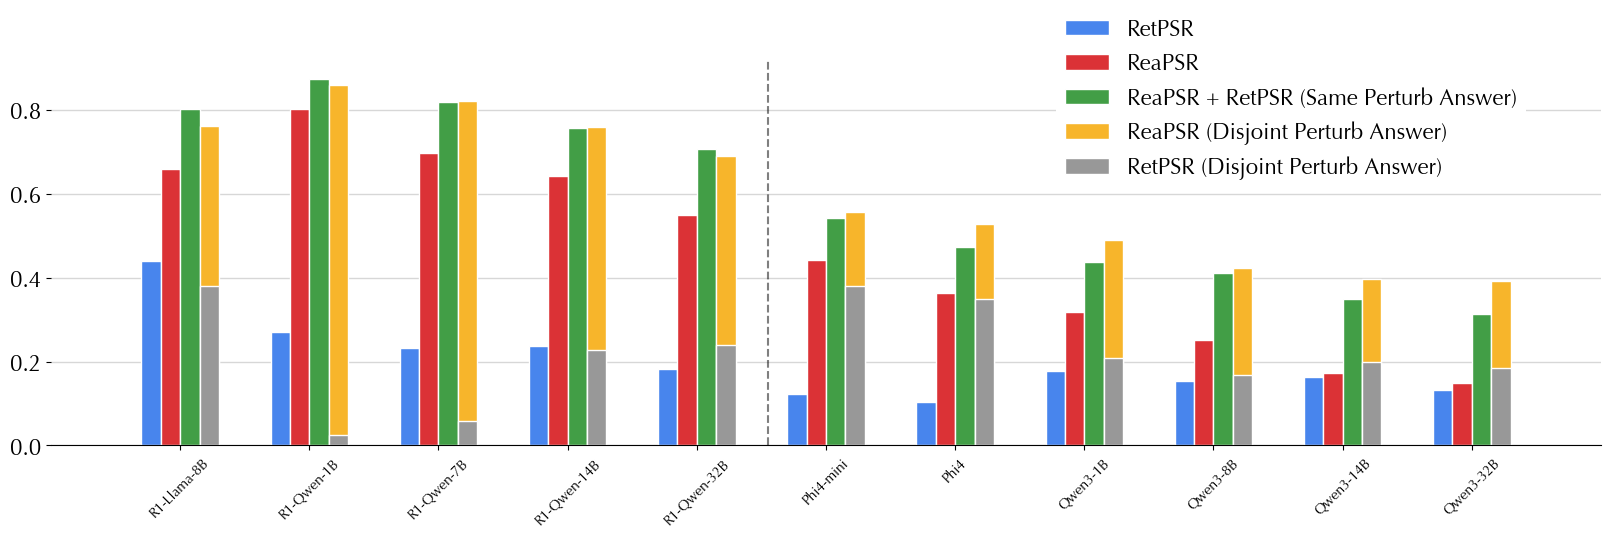

In [8]:
# distill model vs non-distill model
distillmodel_name_list = ['r1llama', 'r1qwen1b', 'r1qwen', 'r1qwen14b', 'r1qwen32b']
distill_model_label_list = ["R1-Llama-8B","R1-Qwen-1B", "R1-Qwen-7B", "R1-Qwen-14B", "R1-Qwen-32B"]
non_distill_model_name_list = ["phi", "phibig", "qwen31b", "qwen3", "qwen314b", "qwen332b"]
non_distill_model_label_list = ["Phi4-mini","Phi4", "Qwen3-1B", "Qwen3-8B", "Qwen3-14B", "Qwen3-32B"]

# distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
# distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])



# sort_index1 = np.argsort(distill_FSR_list)
# sort_index2 = np.argsort(non_distill_FSR_list)

# distillmodel_name_list = [distillmodel_name_list[i] for i in sort_index1]
# non_distill_model_name_list = [non_distill_model_name_list[i] for i in sort_index2]

distill_bar1_list = np.array([total_dic[model_name]["FSR_ICR"] for model_name in distillmodel_name_list])
distill_bar2_list = np.array([total_dic[model_name]["CCR"] for model_name in distillmodel_name_list])
distill_bar3_list = np.array([total_dic[model_name]["is_same"] for model_name in distillmodel_name_list])
distill_bar4_list = np.array([total_dic[model_name]["not_same_back"] for model_name in distillmodel_name_list])
distill_bar5_list = np.array([total_dic[model_name]["not_same_forward"] for model_name in distillmodel_name_list])

non_distill_bar1_list = np.array([total_dic[model_name]["FSR_ICR"] for model_name in non_distill_model_name_list])
non_distill_bar2_list = np.array([total_dic[model_name]["CCR"] for model_name in non_distill_model_name_list])
non_distill_bar3_list = np.array([total_dic[model_name]["is_same"] for model_name in non_distill_model_name_list])
non_distill_bar4_list = np.array([total_dic[model_name]["not_same_back"] for model_name in non_distill_model_name_list])
non_distill_bar5_list = np.array([total_dic[model_name]["not_same_forward"] for model_name in non_distill_model_name_list])

fig = Figure(name = 'distill_vs_non_distill', figsize=(20, 5))

# fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
bar1_list = np.concatenate([distill_bar1_list, non_distill_bar1_list])
bar2_list = np.concatenate([distill_bar2_list, non_distill_bar2_list])
bar3_list = np.concatenate([distill_bar3_list, non_distill_bar3_list])
bar4_list = np.concatenate([distill_bar4_list, non_distill_bar4_list])
bar5_list = np.concatenate([distill_bar5_list, non_distill_bar5_list])

width = 0.15
x = np.arange(len(bar1_list))
x1 = x - width/2 * 3
x2 = x - width/2
x3 = x + width/2
x4 = x + width/2 * 3
fig.set_axis_lim("x", piece = len(bar1_list) - 1, lim = (0, len(bar1_list) - 1), labels = distill_model_label_list  + non_distill_model_label_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
fig.bar(x1, bar1_list, width = width, label=bar_label_list[0], color = bar_color_list[0], align= 'center')
fig.bar(x2, bar2_list, width = width, label=bar_label_list[1], color = bar_color_list[1], align= 'center')
fig.bar(x3, bar3_list, width = width, label=bar_label_list[2], color = bar_color_list[2], align= 'center')
fig.bar(x4, bar4_list, width = width, label=bar_label_list[3], color = bar_color_list[3], align= 'center')
fig.bar(x4, bar5_list, width = width, label=bar_label_list[4], color = bar_color_list[4], align= 'center')
fig.set_legend(loc='center', bbox_to_anchor=(0.8, 0.9))
fig.ax.axvline(x = len(distillmodel_name_list) - 3 * width, linestyle = '--', color = 'black', alpha = 0.5)
fig.save(dpi=300)
# ******分开来 overall error rate consistnet/inconsistent比例

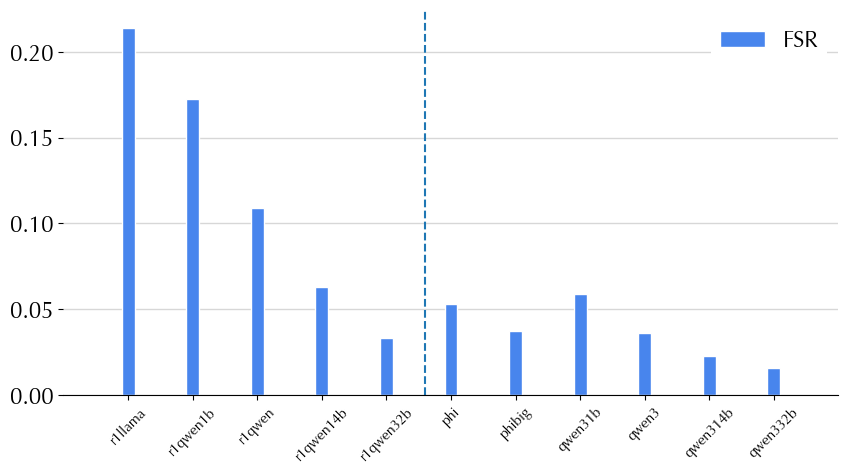

In [9]:
# distill model vs non-distill model
distillmodel_name_list = ['r1llama', 'r1qwen1b', 'r1qwen', 'r1qwen14b', 'r1qwen32b']
non_distill_model_name_list = ["phi", "phibig", "qwen31b", "qwen3", "qwen314b", "qwen332b"]

# distill_FSR_list = np.array([total_dic[model_name]["FSR"] for model_name in distillmodel_name_list])
# distill_ICR_list = np.array([total_dic[model_name]["ICR"] for model_name in distillmodel_name_list])



# sort_index1 = np.argsort(distill_FSR_list)
# sort_index2 = np.argsort(non_distill_FSR_list)

# distillmodel_name_list = [distillmodel_name_list[i] for i in sort_index1]
# non_distill_model_name_list = [non_distill_model_name_list[i] for i in sort_index2]

distill_bar1_list = np.array([total_dic[model_name]["FSR"]  for model_name in distillmodel_name_list])

non_distill_bar1_list = np.array([total_dic[model_name]["FSR"]   for model_name in non_distill_model_name_list])

fig = Figure(name = 'distill_vs_non_distill', figsize=(10, 5))

# fig.set_axis_lim("y", lim = (0, 0.5), piece = 3)
bar1_list = np.concatenate([distill_bar1_list, non_distill_bar1_list])

width = 0.20
x = np.arange(len(bar1_list))
x1 = x
fig.set_axis_lim("x", piece = len(bar1_list) - 1, lim = (0, len(bar1_list) - 1), labels = distillmodel_name_list + non_distill_model_name_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
fig.bar(x1, bar1_list, width = width, label='FSR', color = ting_color["blue_light"], align= 'center')
fig.set_legend()
fig.ax.axvline(x = len(distillmodel_name_list) - 2 * width, linestyle = '--')
# fig.save(dpi=300)
# ******分开来 overall error rate consistnet/inconsistent比例

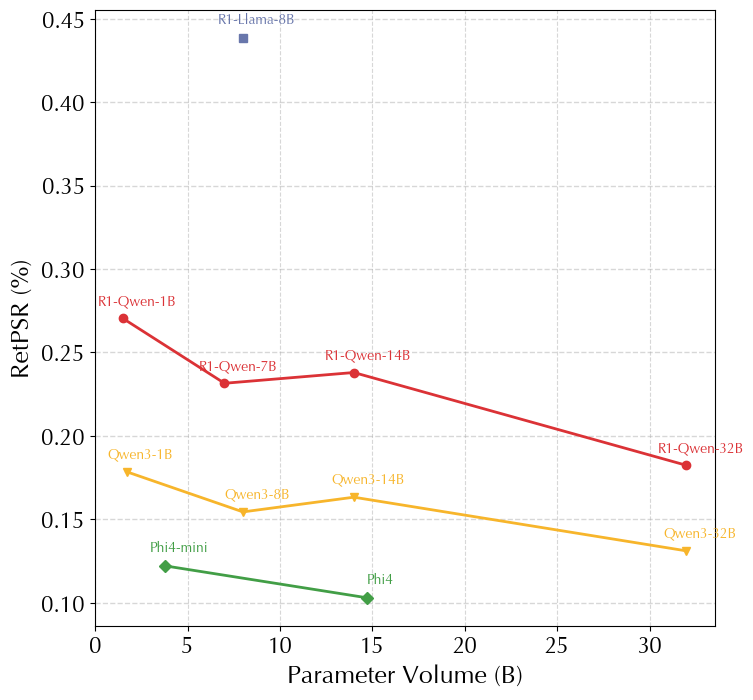

In [10]:
# distill model vs non-distill model

def draw_model_size_FSR(name, key, y_label_name):
    fig = Figure(name = name, figsize=(8, 8))
    fig.ax.grid(True, linestyle = '--', alpha = 0.5)
    # 添加四周的框线
    fig.ax.spines['top'].set_visible(True)
    fig.ax.spines['right'].set_visible(True)
    fig.ax.spines['bottom'].set_visible(True)
    fig.ax.spines['left'].set_visible(True)
    color_list = [ting_color["red"], ting_color["blue"], ting_color["green"], ting_color["yellow"], ting_color["grey"]]

    # r1qwen
    model_size_r1qwen = [1.5,7,14, 32]
    model_name_r1qwen = ["r1qwen1b", "r1qwen" , "r1qwen14b", "r1qwen32b"]
    model_label_r1qwen = ["R1-Qwen-1B", "R1-Qwen-7B", "R1-Qwen-14B", "R1-Qwen-32B"]
    color1 = color_list[0]
    model_score_r1qwen = [total_dic[model_name][key] for model_name in model_name_r1qwen]
    fig.lineplot(model_size_r1qwen, model_score_r1qwen, marker = "o", label='r1qwen', color = color1, markerfacecolor = color1)
    for i, (x, y, name) in enumerate(zip(model_size_r1qwen, model_score_r1qwen, model_label_r1qwen)):
        fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color1)

    # r1llama
    model_size_r1llama = [8]
    model_name_r1llama = ["r1llama"]
    model_label_r1llama = ["R1-Llama-8B"]
    color2 = color_list[1]
    model_score_r1llama = [total_dic[model_name][key] for model_name in model_name_r1llama]
    fig.lineplot(model_size_r1llama, model_score_r1llama, marker = "s", label='r1llama', color = color2, markerfacecolor=color2)
    for i, (x, y, name) in enumerate(zip(model_size_r1llama, model_score_r1llama, model_label_r1llama)):
        fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color2)

    # phi
    model_size_phi = [3.8, 14.7]
    model_name_phi = ["phi", "phibig"]
    model_label_phi = ["Phi4-mini", "Phi4"]
    color4 = color_list[2]
    model_score_phi = [total_dic[model_name][key] for model_name in model_name_phi]
    fig.lineplot(model_size_phi, model_score_phi, marker = "D", label='phi', color = color4, markerfacecolor=color4)
    for i, (x, y, name) in enumerate(zip(model_size_phi, model_score_phi, model_label_phi)):
        fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color4)

    # qwen3
    model_size_qwen3 = [1.7,8, 14, 32]
    model_name_qwen3 = ["qwen31b", "qwen3", "qwen314b", "qwen332b"]
    model_label_qwen3 = ["Qwen3-1B", "Qwen3-8B", "Qwen3-14B", "Qwen3-32B"]
    color5 = color_list[3]
    model_score_qwen3 = [total_dic[model_name][key] for model_name in model_name_qwen3]
    fig.lineplot(model_size_qwen3, model_score_qwen3, marker = "v", label='qwen3', color = color5, markerfacecolor=color5)
    for i, (x, y, name) in enumerate(zip(model_size_qwen3, model_score_qwen3, model_label_qwen3)):
        fig.ax.annotate(name, (x, y), textcoords="offset points", xytext=(10,10), ha='center', color = color5)

    # fig.set_legend()

    # fig.ax.set_xscale('log')
    fig.set_axis_label(axis = "x", text = "Parameter Volume (B)")
    fig.set_axis_label(axis = "y", text = y_label_name + " (%)")
    fig.save(dpi=300)

    plt.show()
draw_model_size_FSR('model_size_RetPSR', "FSR_ICR", bar_label_list[0])

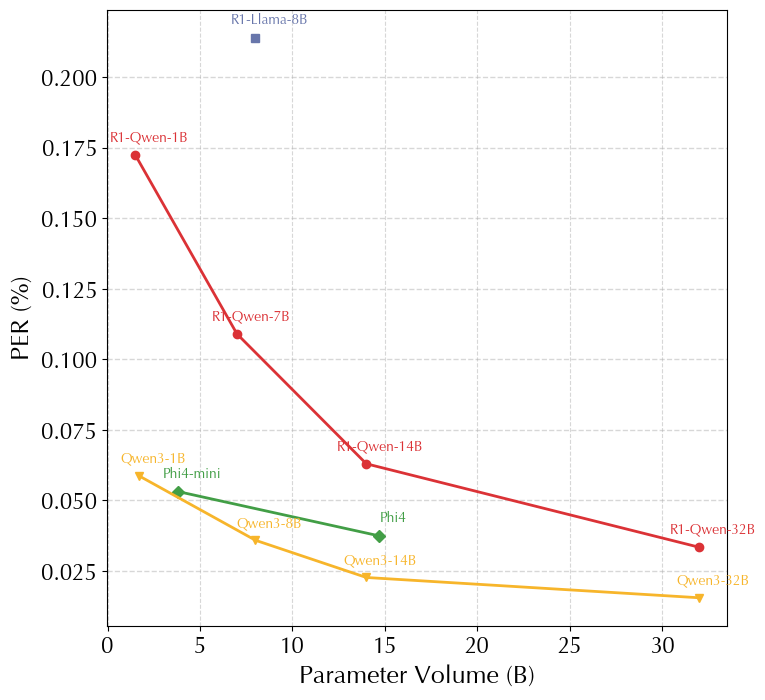

In [11]:
draw_model_size_FSR('model_size_FSR', "FSR", "PER")

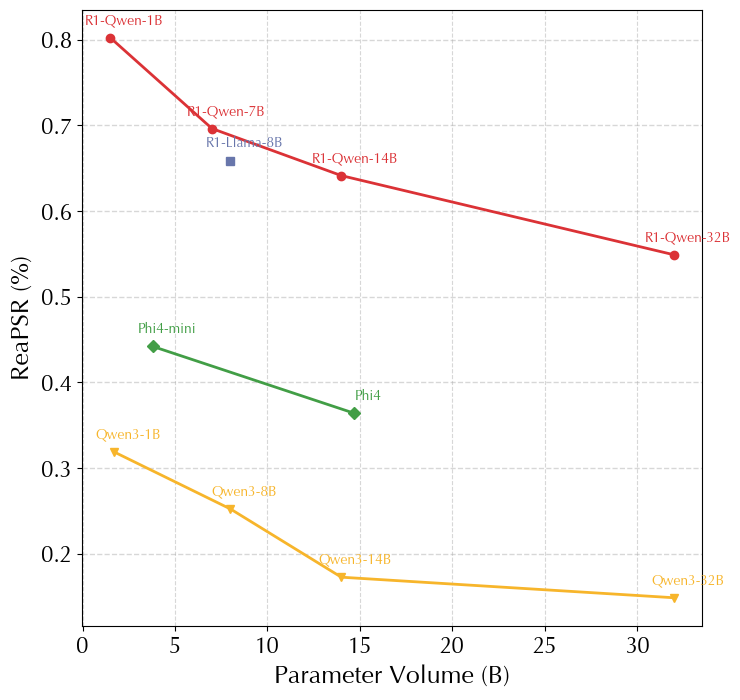

In [12]:
draw_model_size_FSR('model_size_ReaPSR', "CCR", bar_label_list[1])

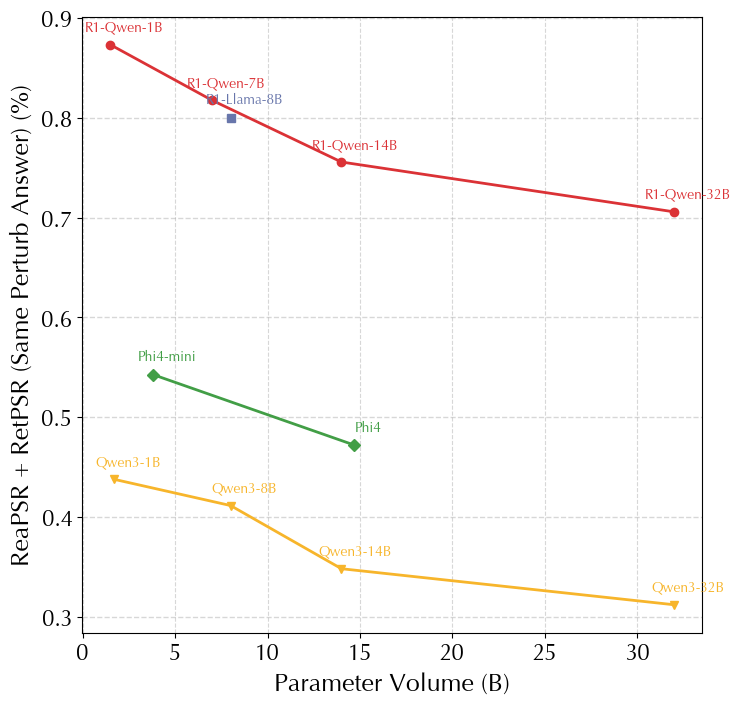

In [13]:
draw_model_size_FSR('model_size_same_perturb', "is_same", bar_label_list[2])

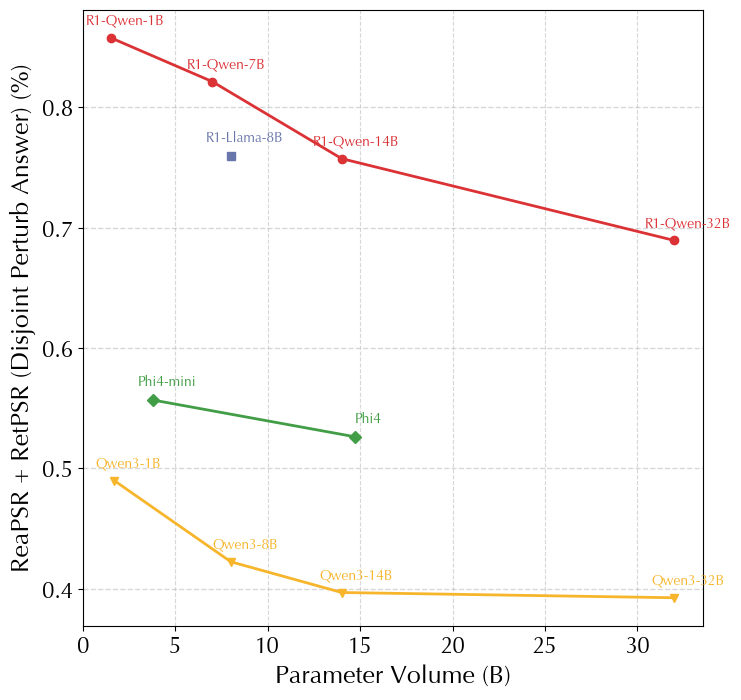

In [14]:
draw_model_size_FSR('model_size_dis_perturb', "not_same_back", bar_label_list[5])

In [15]:
# draw_model_size_FSR('model_size_FSR', "not_same_forward")

In [16]:
# # distill model vs non-distill model

# fig = Figure(name = 'model_size_FSR', figsize=(5, 5))

# # r1qwen
# model_size_r1qwen = [1.5,7,14]
# model_name_r1qwen = ["r1qwen1b", "r1qwen" , "r1qwen14b"]
# # model_score_r1qwen = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1qwen]
# model_score_r1qwen = [total_dic[model_name]["FSR"] for model_name in model_name_r1qwen]
# fig.lineplot(model_size_r1qwen, model_score_r1qwen, marker = "o", label='r1qwen')


# # r1llama
# model_size_r1llama = [8]
# model_name_r1llama = ["r1llama"]
# model_score_r1llama = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1llama]
# fig.lineplot(model_size_r1llama, model_score_r1llama, marker = "o", label='r1llama')

# # r1qwen3
# model_size_r1qwen3 = [8]
# model_name_r1qwen3 = ["r1qwen3"]
# model_score_r1qwen3 = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_r1qwen3]
# fig.lineplot(model_size_r1qwen3, model_score_r1qwen3, marker = "o", label='r1qwen3')

# # phi
# model_size_phi = [3]
# model_name_phi = ["phi"]
# model_score_phi = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_phi]
# fig.lineplot(model_size_phi, model_score_phi, marker = "o", label='phi')

# # qwen3
# model_size_qwen3 = [8]
# model_name_qwen3 = ["qwen3"]
# model_score_qwen3 = [total_dic[model_name]["FSR"] + total_dic[model_name]["ICR"] for model_name in model_name_qwen3]
# fig.lineplot(model_size_qwen3, model_score_qwen3, marker = "o", label='qwen3')

# fig.set_legend()

# plt.show()

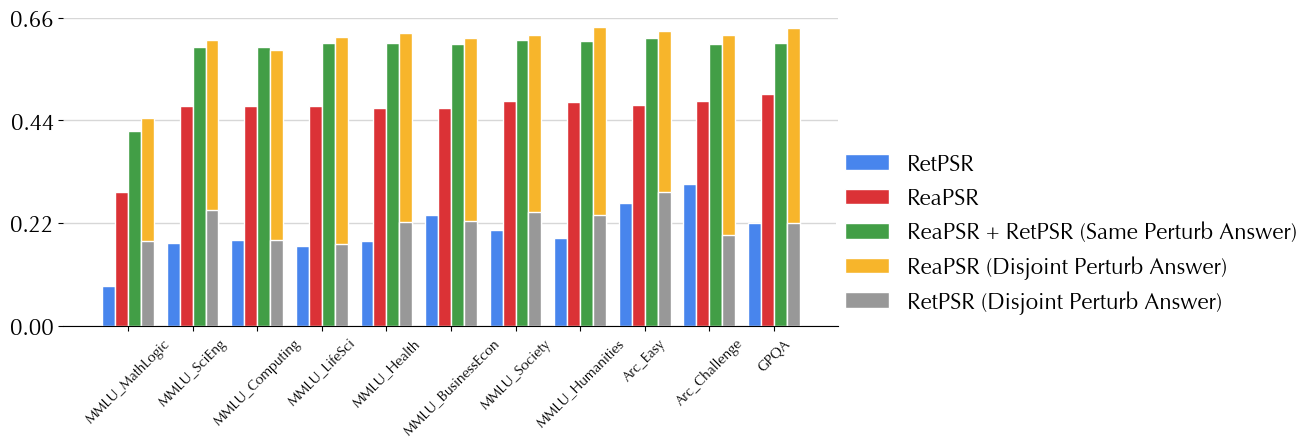

In [17]:
group_RPSR_list = []
# group_RPSR_list_std = []
group_RETPSR_list = []
# group_RETPSR_list_std = []
group_issame_list = []
group_notsame_list_back = []
group_notsame_list_forward = []

for group in group_name_list:
    temp_list_RPSR = []
    temp_list_RETPSR = []
    temp_list_issame = []
    temp_list_notsame_back = []
    temp_list_notsame_forward = []
    for model_name in model_name_list:
        temp_list_RPSR.append(total_dic[model_name][group][0][0] + total_dic[model_name][group][0][1])
        temp_list_RETPSR.append(total_dic[model_name][group][1])
        temp_list_issame.append(total_dic[model_name][group][2])
        temp_list_notsame_back.append(total_dic[model_name][group][3][0] + total_dic[model_name][group][3][1])
        temp_list_notsame_forward.append(total_dic[model_name][group][3][0])
    group_RPSR_list.append(np.mean(temp_list_RPSR))
    # group_RPSR_list_std.append(np.std(temp_list_RPSR))
    group_RETPSR_list.append(np.mean(temp_list_RETPSR))
    # group_RETPSR_list_std.append(np.std(temp_list_RETPSR))
    group_issame_list.append(np.mean(temp_list_issame))
    group_notsame_list_back.append(np.mean(temp_list_notsame_back))
    group_notsame_list_forward.append(np.mean(temp_list_notsame_forward))

# 按FSR排序所有数据
combined_data = list(zip(group_name_list, group_RPSR_list, group_RETPSR_list, group_issame_list, group_notsame_list_back, group_notsame_list_forward))
# 按FSR值降序排序（索引1是FSR值）
sorted_data = sorted(combined_data, key=lambda x: x[1])

# 解压排序后的数据
sorted_group_names, sorted_RPSR_list, sorted_RETPSR_list, sorted_issame_list, sorted_notsame_list_back, sorted_notsame_list_forward = zip(*sorted_data)

fig = Figure(name = 'group_rate', figsize=(10, 4))
width = 0.2
x = np.arange(len(sorted_group_names))
x1 = x - width/2 * 3
x2 = x -  width/2
x3 = x + width/2
x4 = x + width/2 * 3
fig.set_axis_lim("x", piece = len(sorted_group_names) - 1, lim = (0, len(sorted_group_names) - 1), labels = group_label_list, margin=(1,1), fontdict = {'fontsize': 10}, rotation = 45)
fig.set_axis_lim("y", lim = (0, 0.66), piece = 3)
fig.bar(x1, group_RPSR_list, width = width, label=bar_label_list[0], color = bar_color_list[0], align= 'center')
fig.bar(x2, group_RETPSR_list, width = width, label=bar_label_list[1], color = bar_color_list[1], align= 'center')
fig.bar(x3, group_issame_list, width = width, label=bar_label_list[2], color = bar_color_list[2], align= 'center')
fig.bar(x4, group_notsame_list_back, width = width, label=bar_label_list[3], color = bar_color_list[3], align= 'center')
fig.bar(x4, group_notsame_list_forward, width = width, label=bar_label_list[4], color = bar_color_list[4], align= 'center')
fig.set_legend(loc = 'center', bbox_to_anchor=(1.3, 0.3))
fig.save(dpi=300)
plt.show()


auc_matrix_filtered shape: (32, 32)


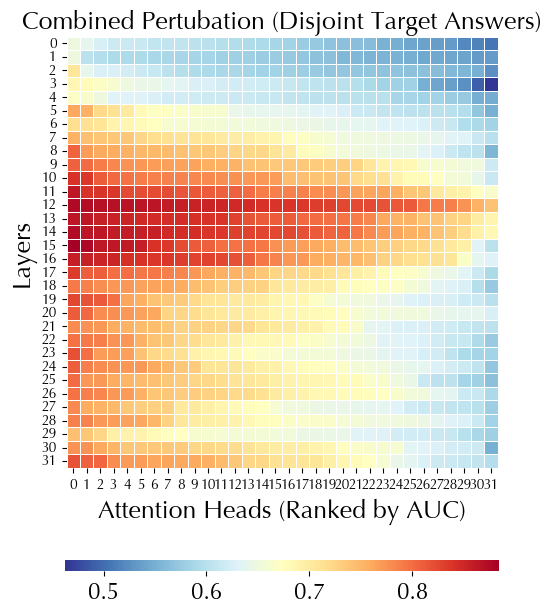

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
from alpsplot.figure import Figure
from alpsplot.colormap import tab20c_color, ting_color




def draw_attention_map(save_dir, short_model_name, group_name, model_label, group_label, title):
    name = f"{short_model_name}_{group_name}_{save_dir.split('/')[-1]}"
    fig = Figure(name = name, figsize=(8, 8))
    # load the auc_matrix_filtered
    auc_matrix = np.load(f'{save_dir}/{short_model_name}_{group_name}_auc_matrix_filtered.npy')
    print(f"auc_matrix_filtered shape: {auc_matrix.shape}")

    # Sort each row in descending order (larger values first)
    sorted_auc_matrix = np.zeros_like(auc_matrix)
    for i in range(auc_matrix.shape[0]):
        sorted_indices = np.argsort(auc_matrix[i])[::-1]  # Sort in descending order
        sorted_auc_matrix[i] = auc_matrix[i][sorted_indices]

    # Create a more polished heatmap
    # plt.figure(figsize=(10, 10))
    # plt.rcParams['font.size'] = 10

    # Use a better colormap and customize the heatmap
    ax = sns.heatmap(sorted_auc_matrix, 
                        # annot=True, 
                        fmt='.1f',  # Show 3 decimal places for better readability
                        cmap='RdYlBu_r',  # Red-Yellow-Blue reversed (red=high, blue=low)
                        cbar_kws={'orientation': 'horizontal', "shrink": 0.7, 'aspect': 40, #'label': 'AUC'
                        },
                        linewidths=0.5,  # Add grid lines between cells
                        square=True)  # Make cells square-shaped

    ax.set_xticks(np.arange(len(sorted_auc_matrix[0])) + 0.5)   # 每列中点
    ax.set_xticklabels(range(len(sorted_auc_matrix[0])), rotation=0, fontsize=10)  # 或 rotation=0

    ax.set_yticks(np.arange(len(sorted_auc_matrix)) + 0.5)   # 每行中点
    ax.set_yticklabels(range(len(sorted_auc_matrix)), rotation=0, fontsize=10)
    # x = np.arange(32)
    # fig.set_axis_lim("x", piece = len(x) - 1, lim = (0, len(x) - 1), labels = x, margin=(1,1), ≈, rotation = 0)


    # Improve the plot appearance
    fig.set_title(title)
    fig.set_axis_label('x', 'Attention Heads (Ranked by AUC)')
    fig.set_axis_label('y', 'Layers')
    fig.save(dpi=300)
    # plt.title(f'AUC Heatmap: {SHORT_MODEL_NAME} - {GROUP_NAME}\n(Rows sorted by AUC values, highest first)', 
    #             fontsize=16, fontweight='bold', pad=20)
    # plt.xlabel('Feature Index (sorted by AUC)', fontsize=14, fontweight='bold')
    # plt.ylabel('Layer/Head Group', fontsize=14, fontweight='bold')

SAVE_DIR = "/data/yuhui/8/memory-perturb/atten_map"
SHORT_MODEL_NAME = "r1llama"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Llama-8B"
GROUP_LABEL = "Math&Logic"

draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, "Combined Pertubation (Disjoint Target Answers)")



auc_matrix_filtered shape: (32, 32)


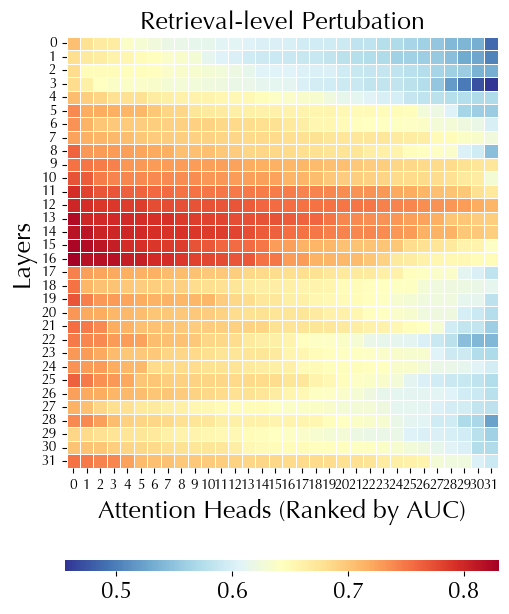

In [63]:
SAVE_DIR = "/data/yuhui/8/memory-perturb/atten_map_memory"
SHORT_MODEL_NAME = "r1llama"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Llama-8B"
GROUP_LABEL = "Math&Logic"

draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, "Retrieval-level Pertubation")

auc_matrix_filtered shape: (32, 32)


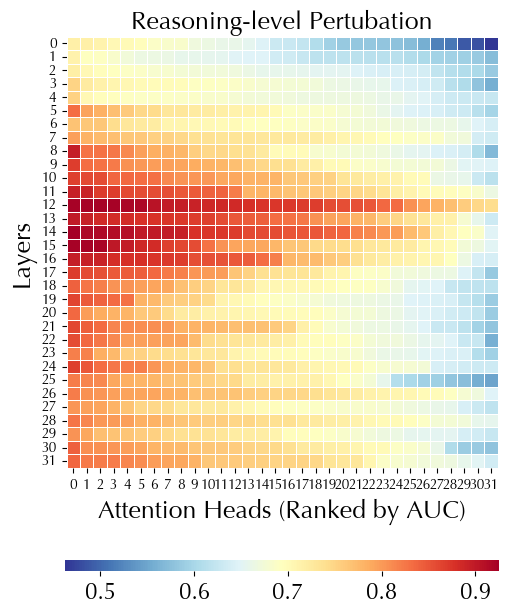

In [64]:
SAVE_DIR = "/data/yuhui/8/memory-perturb/atten_map_cot"
SHORT_MODEL_NAME = "r1llama"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Llama-8B"
GROUP_LABEL = "Math&Logic"

draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, "Reasoning-level Pertubation")

auc_matrix_filtered shape: (32, 32)


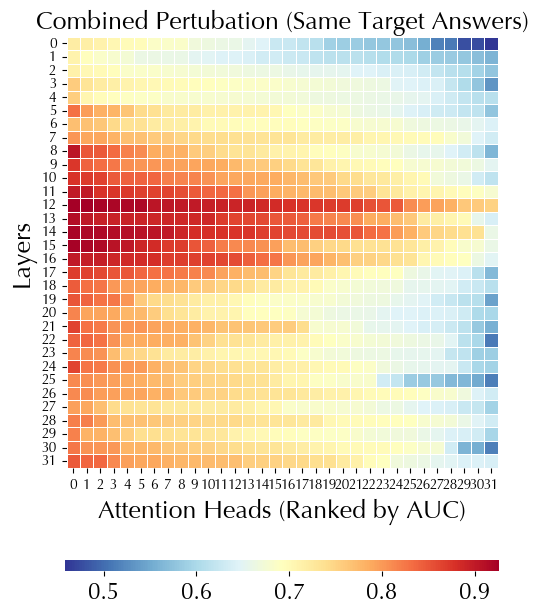

In [65]:
SAVE_DIR = "/data/yuhui/8/memory-perturb/atten_map_combined_same"
SHORT_MODEL_NAME = "r1llama"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Llama-8B"
GROUP_LABEL = "Math&Logic"
TITLE = "Combined Pertubation (Same Target Answers)"

draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)


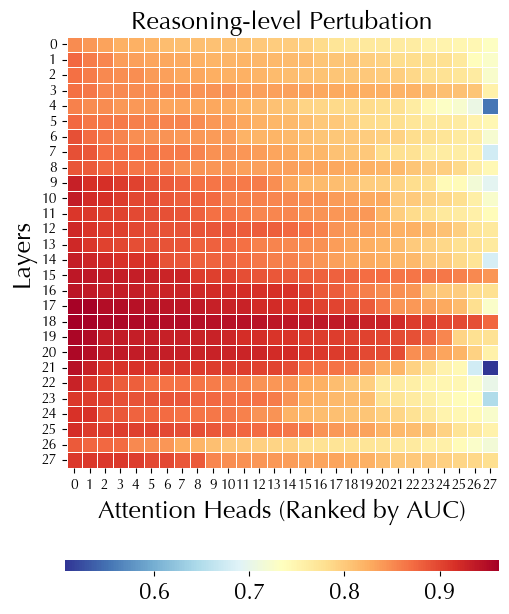

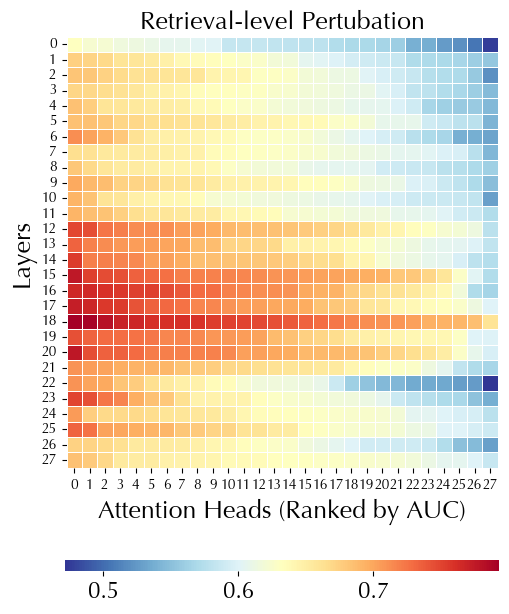

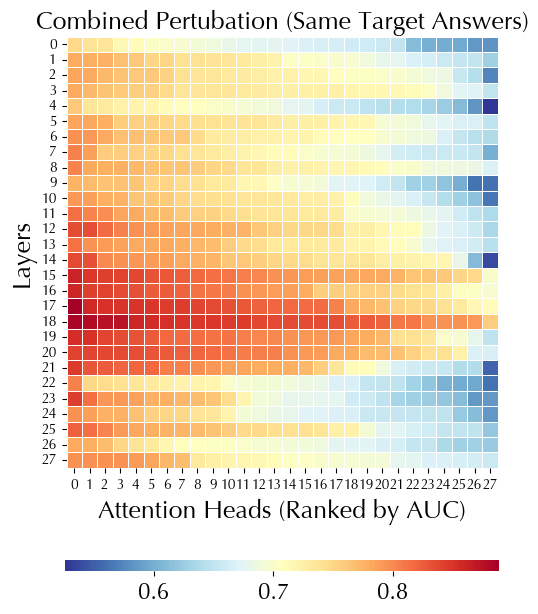

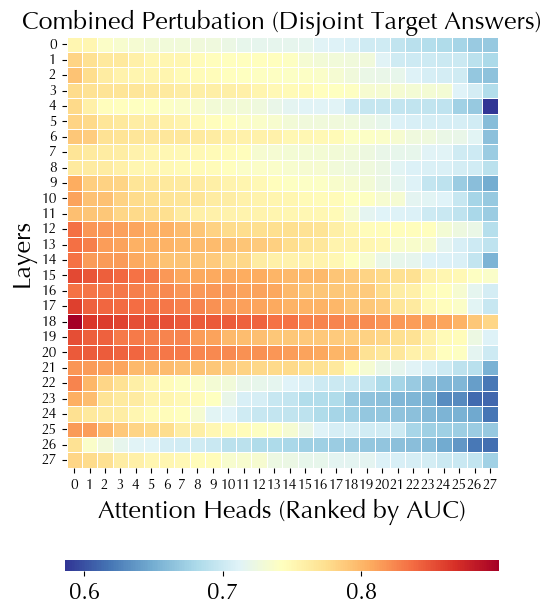

In [66]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1qwen"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Qwen-7B"
GROUP_LABEL = "Math&Logic"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)


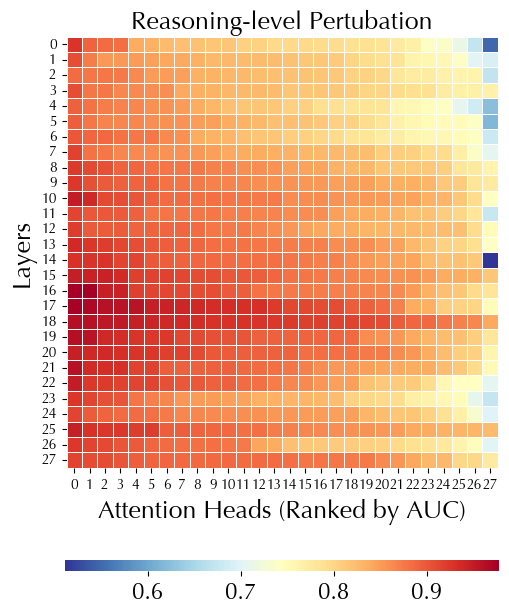

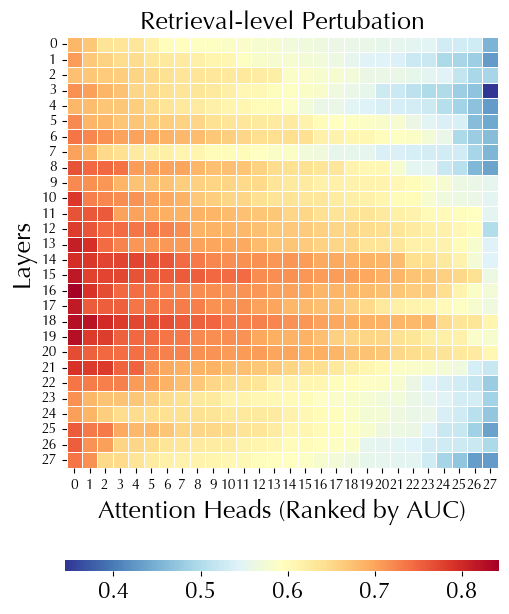

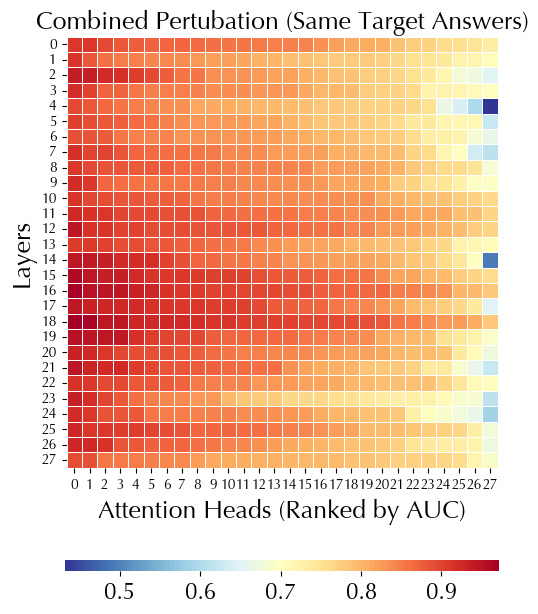

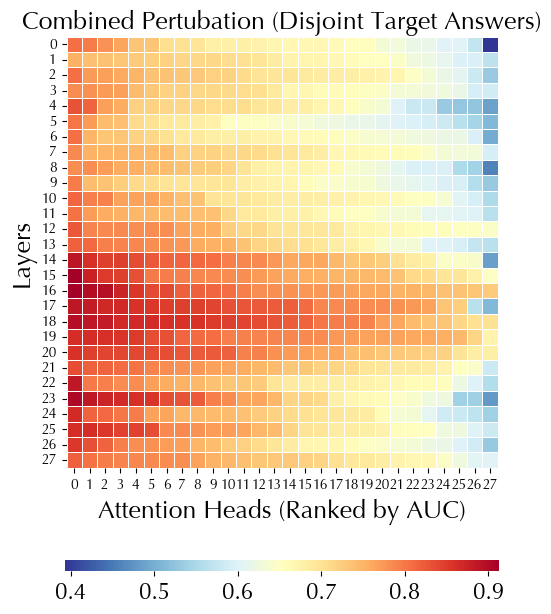

In [67]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1qwen"
GROUP_NAME = "Computing"
MODEL_LABEL = "R1-Qwen-7B"
GROUP_LABEL = "Computing"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)


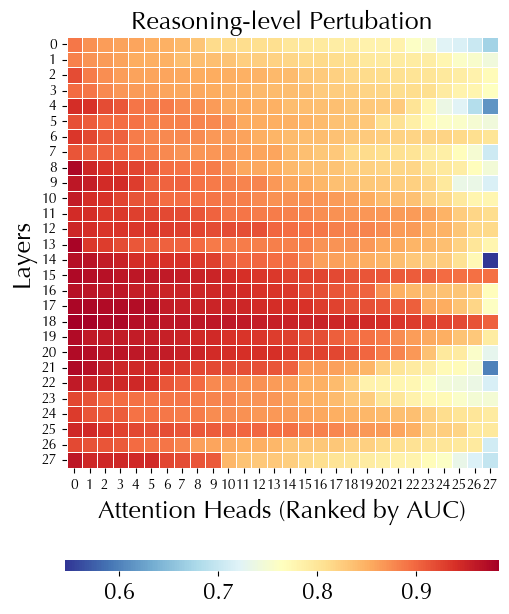

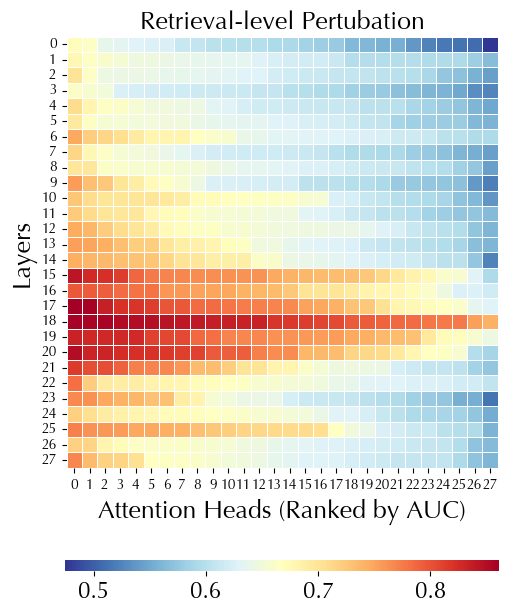

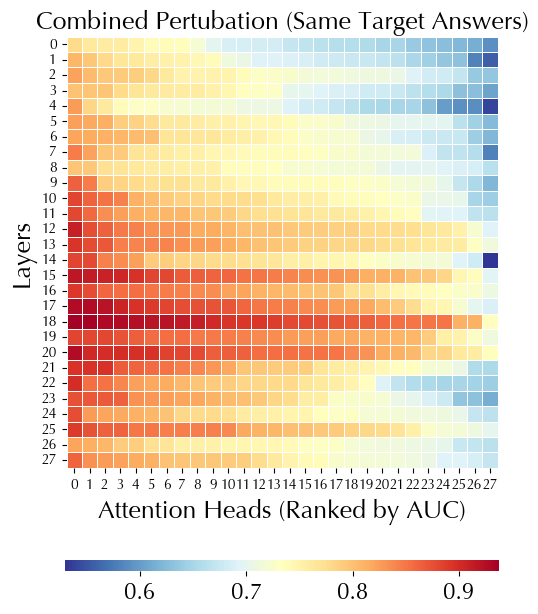

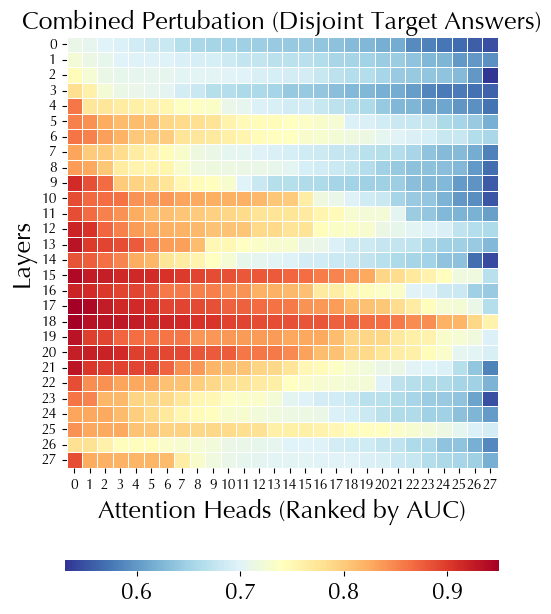

In [68]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1qwen"
GROUP_NAME = "SciEng"
MODEL_LABEL = "R1-Qwen-7B"
GROUP_LABEL = "SciEng"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)


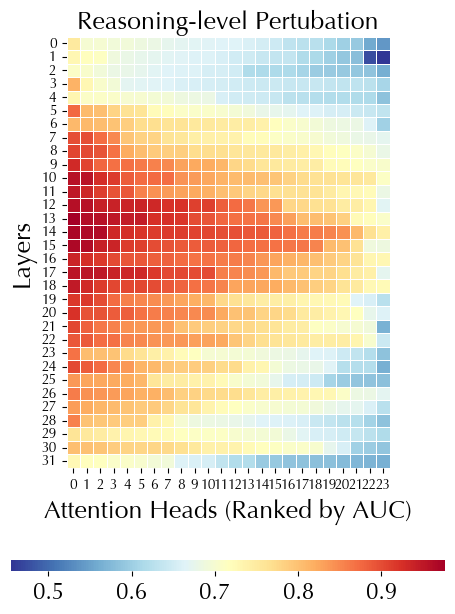

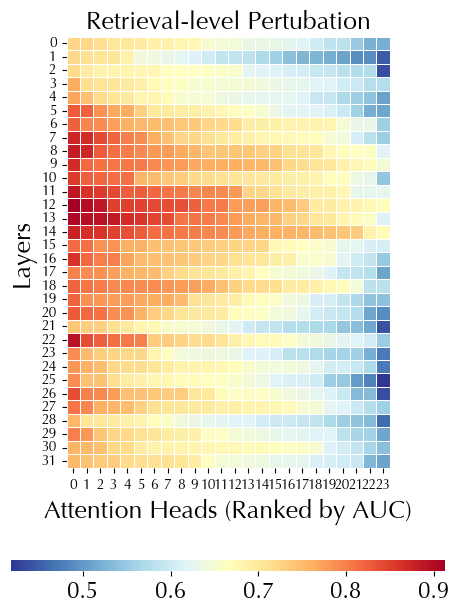

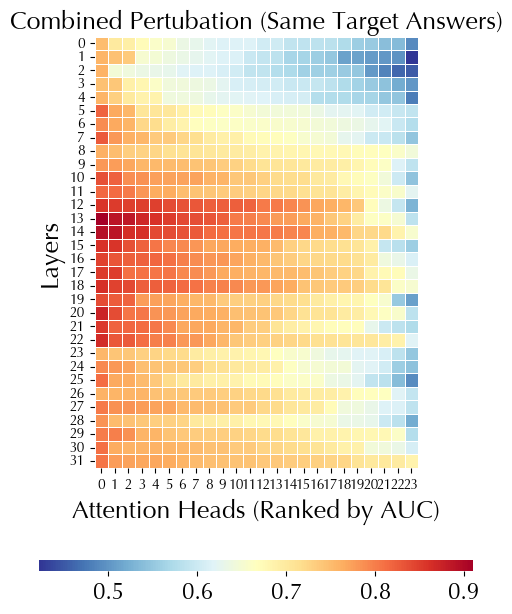

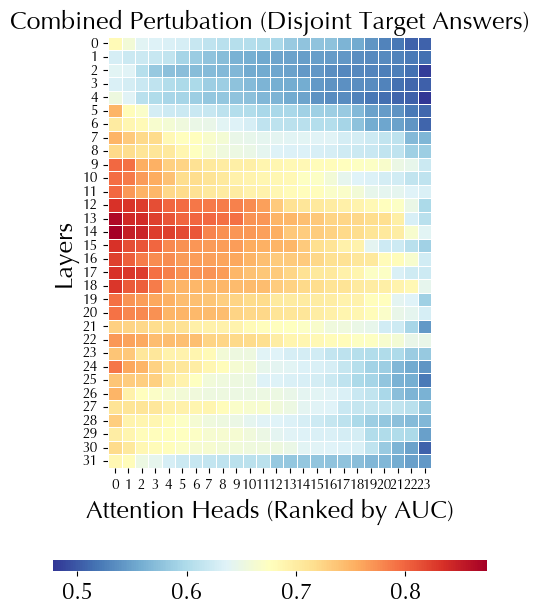

In [69]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "phi"
GROUP_NAME = "Computing"
MODEL_LABEL = "Phi4-mini-reasoning"
GROUP_LABEL = "Computing"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)


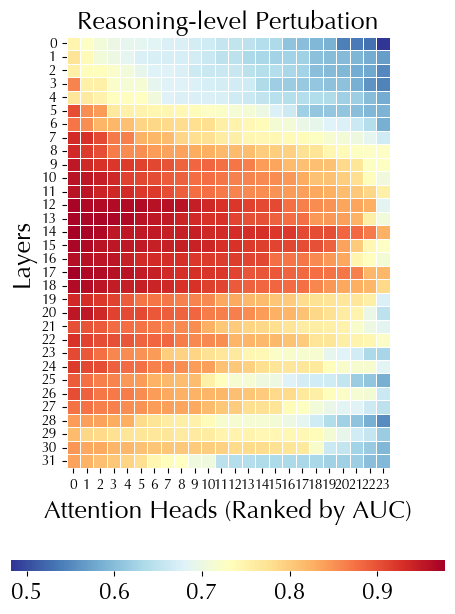

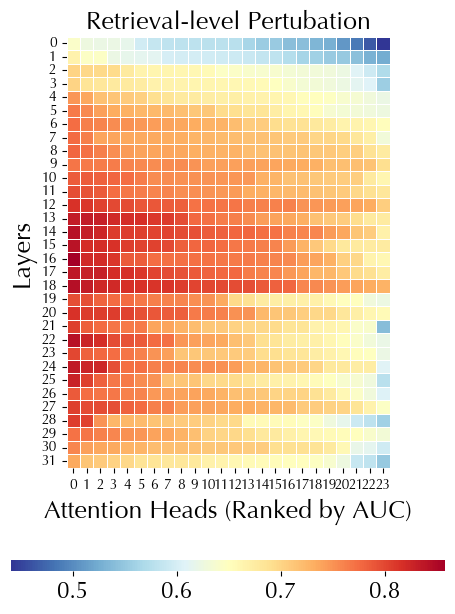

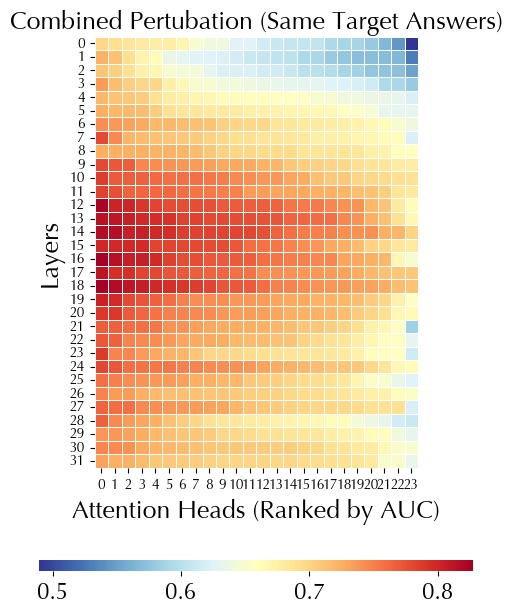

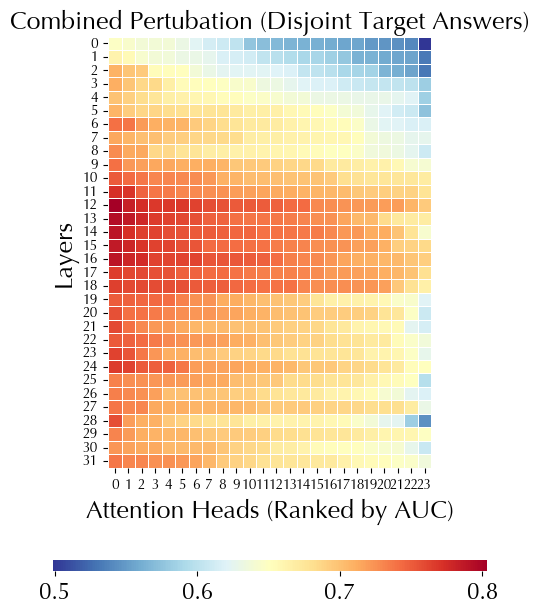

In [70]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "phi"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "Phi4-mini-reasoning"
GROUP_LABEL = "Math&Logic"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)


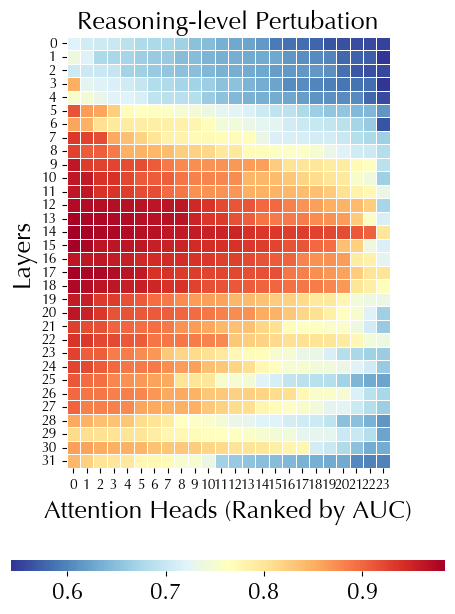

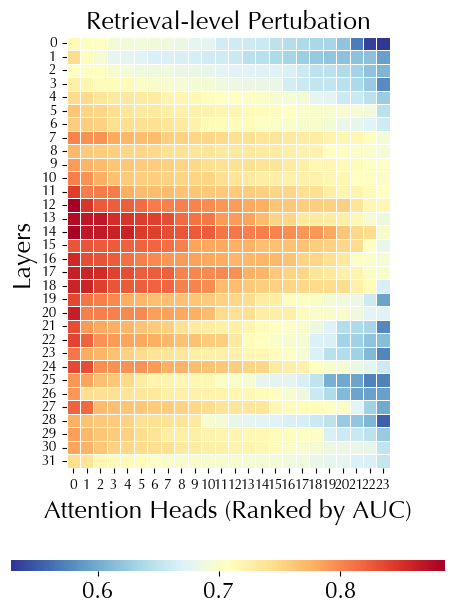

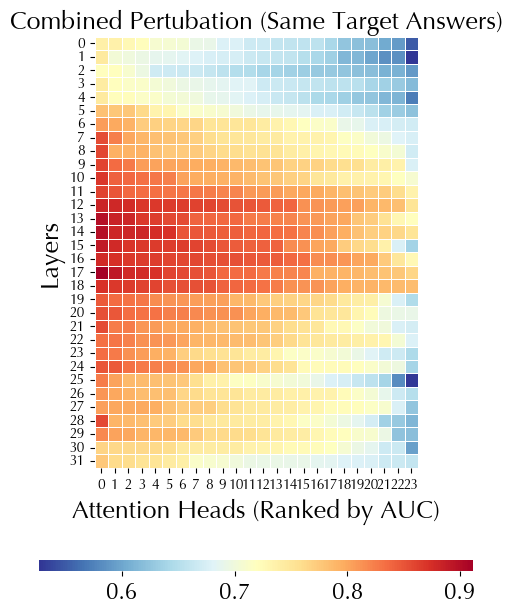

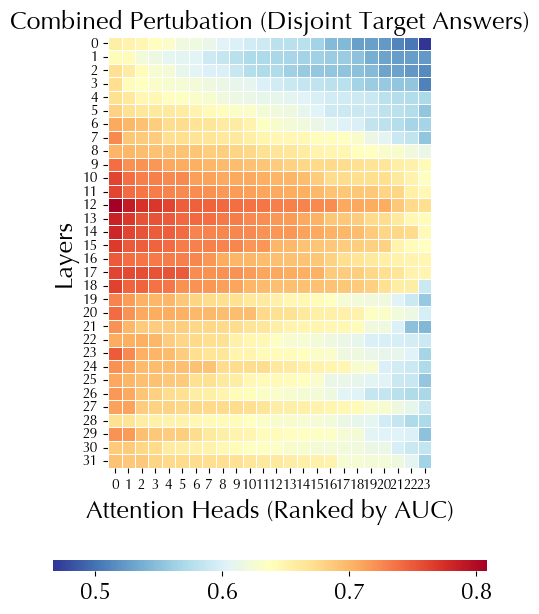

In [71]:
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "phi"
GROUP_NAME = "SciEng"
MODEL_LABEL = "Phi4-mini-reasoning"
GROUP_LABEL = "SciEng"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation (Same Target Answers)", "Combined Pertubation (Disjoint Target Answers)"]

for SAVE_DIR, TITLE in zip(SAVE_DIRS, TITLES):
    draw_attention_map(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE)

auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)


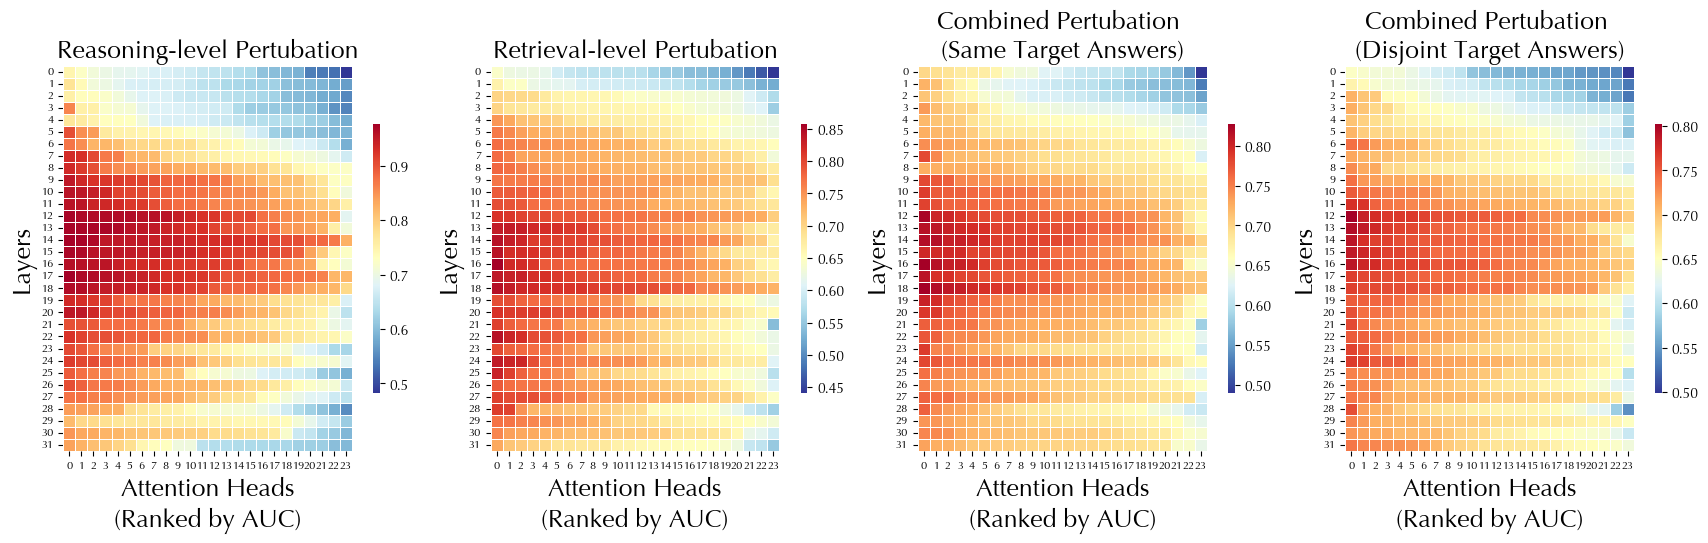

In [100]:
fig_all, axes = plt.subplots(1, 4, figsize=(22, 5))
fig_all.subplots_adjust(wspace=0.01, hspace=0.1)  # wspace是宽度间距，hspace是高度间距
def draw_attention_map_ax(save_dir, short_model_name, group_name, model_label, group_label, title, ax):
    name = f"{short_model_name}_{group_name}_{save_dir.split('/')[-1]}"
    fig = Figure(name = name, figsize=(8, 8), ax = ax)
    # load the auc_matrix_filtered
    auc_matrix = np.load(f'{save_dir}/{short_model_name}_{group_name}_auc_matrix_filtered.npy')
    print(f"auc_matrix_filtered shape: {auc_matrix.shape}")

    # Sort each row in descending order (larger values first)
    sorted_auc_matrix = np.zeros_like(auc_matrix)
    for i in range(auc_matrix.shape[0]):
        sorted_indices = np.argsort(auc_matrix[i])[::-1]  # Sort in descending order
        sorted_auc_matrix[i] = auc_matrix[i][sorted_indices]

    # Create a more polished heatmap
    # plt.figure(figsize=(10, 10))
    # plt.rcParams['font.size'] = 10

    # Use a better colormap and customize the heatmap
    sns.heatmap(sorted_auc_matrix, 
                        # annot=True, 
                        fmt='.1f',  # Show 3 decimal places for better readability
                        cmap='RdYlBu_r',  # Red-Yellow-Blue reversed (red=high, blue=low)
                        cbar_kws={'orientation': 'vertical', "shrink": 0.7, 'aspect': 40, #'label': 'AUC'
                        },
                        linewidths=0.5,  # Add grid lines between cells
                        square=True,
                        ax = ax)  # Make cells square-shaped
    cbar = ax.collections[0].colorbar
    # cbar.set_label('AUC', fontsize=12)      # label font size
    cbar.ax.tick_params(labelsize=10) 

    ax.set_xticks(np.arange(len(sorted_auc_matrix[0])) + 0.5)   # 每列中点
    ax.set_xticklabels(range(len(sorted_auc_matrix[0])), rotation=0, fontsize=8)  # 或 rotation=0

    ax.set_yticks(np.arange(len(sorted_auc_matrix)) + 0.5)   # 每行中点
    ax.set_yticklabels(range(len(sorted_auc_matrix)), rotation=0, fontsize=8)
    # x = np.arange(32)
    # fig.set_axis_lim("x", piece = len(x) - 1, lim = (0, len(x) - 1), labels = x, margin=(1,1), ≈, rotation = 0)


    # Improve the plot appearance
    fig.set_title(title)
    fig.set_axis_label('x', 'Attention Heads\n(Ranked by AUC)')
    fig.set_axis_label('y', 'Layers')
    # fig.save(dpi=300)
    # plt.title(f'AUC Heatmap: {SHORT_MODEL_NAME} - {GROUP_NAME}\n(Rows sorted by AUC values, highest first)', 
    #             fontsize=16, fontweight='bold', pad=20)
    # plt.xlabel('Feature Index (sorted by AUC)', fontsize=14, fontweight='bold')
    # plt.ylabel('Layer/Head Group', fontsize=14, fontweight='bold')
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "phi"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "Phi4-mini-reasoning"
GROUP_LABEL = "Math&Logic"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation \n(Same Target Answers)", "Combined Pertubation \n(Disjoint Target Answers)"]
for idx, (SAVE_DIR, TITLE) in enumerate(zip(SAVE_DIRS, TITLES)):
    draw_attention_map_ax(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE, axes[idx])
path = f"output/{SHORT_MODEL_NAME}_{GROUP_NAME}_atten_map_all.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)


auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)
auc_matrix_filtered shape: (32, 24)


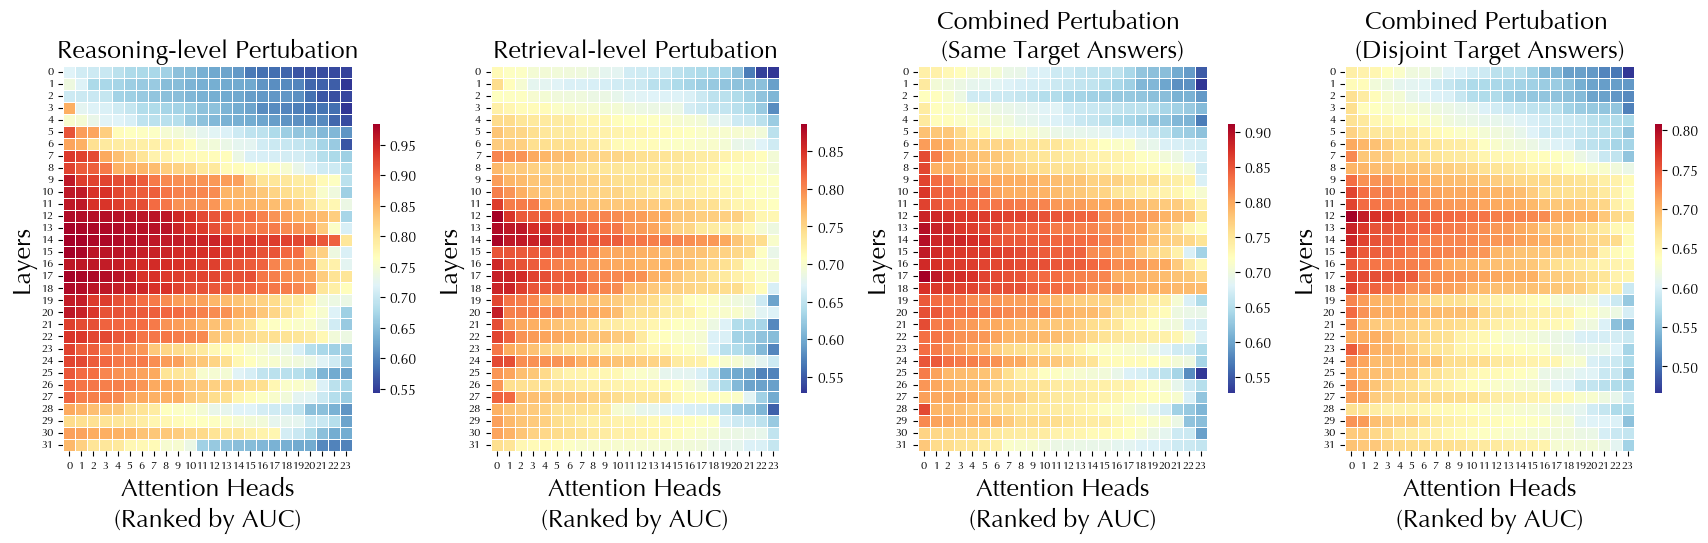

In [102]:
fig_all, axes = plt.subplots(1, 4, figsize=(22, 5))
fig_all.subplots_adjust(wspace=0.01, hspace=0.1)  # wspace是宽度间距，
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "phi"
GROUP_NAME = "SciEng"
MODEL_LABEL = "Phi4-mini-reasoning"
GROUP_LABEL = "SciEng"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation \n(Same Target Answers)", "Combined Pertubation \n(Disjoint Target Answers)"]
for idx, (SAVE_DIR, TITLE) in enumerate(zip(SAVE_DIRS, TITLES)):
    draw_attention_map_ax(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE, axes[idx])
path = f"output/{SHORT_MODEL_NAME}_{GROUP_NAME}_atten_map_all.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)


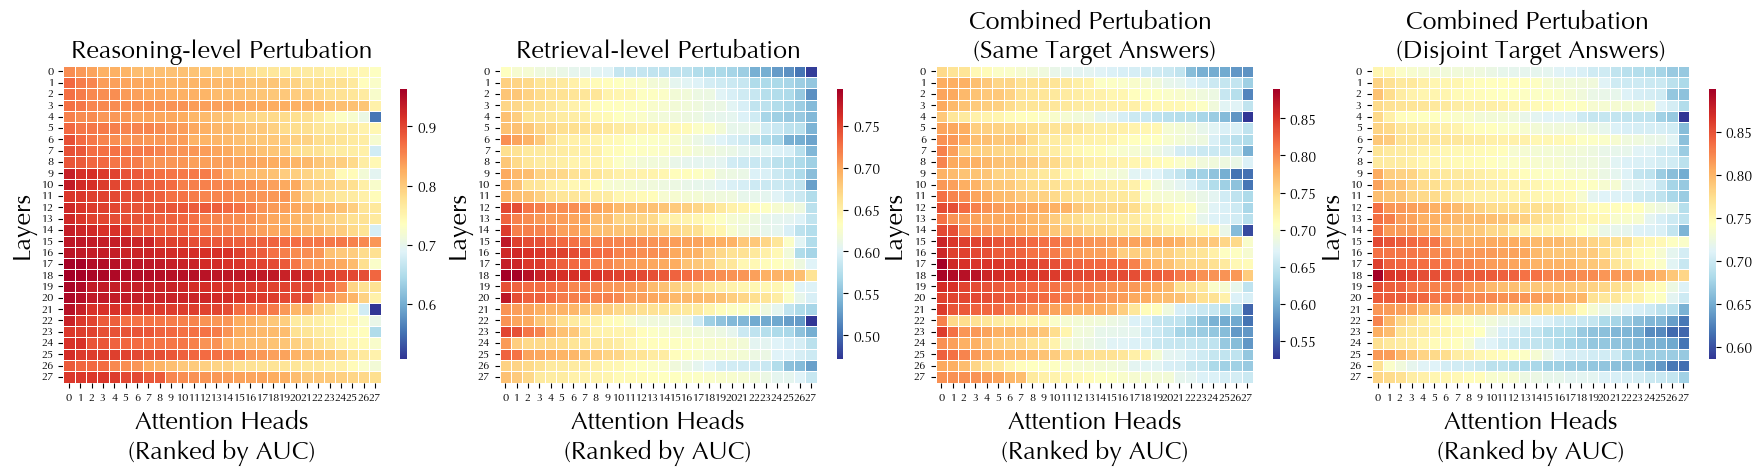

In [104]:
fig_all, axes = plt.subplots(1, 4, figsize=(22, 5))
fig_all.subplots_adjust(wspace=0.1, hspace=0.1)  # wspace是宽度间距，
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1qwen"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Qwen-7B"
GROUP_LABEL = "Math&Logic"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation \n(Same Target Answers)", "Combined Pertubation \n(Disjoint Target Answers)"]
for idx, (SAVE_DIR, TITLE) in enumerate(zip(SAVE_DIRS, TITLES)):
    draw_attention_map_ax(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE, axes[idx])
path = f"output/{SHORT_MODEL_NAME}_{GROUP_NAME}_atten_map_all.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)
auc_matrix_filtered shape: (28, 28)


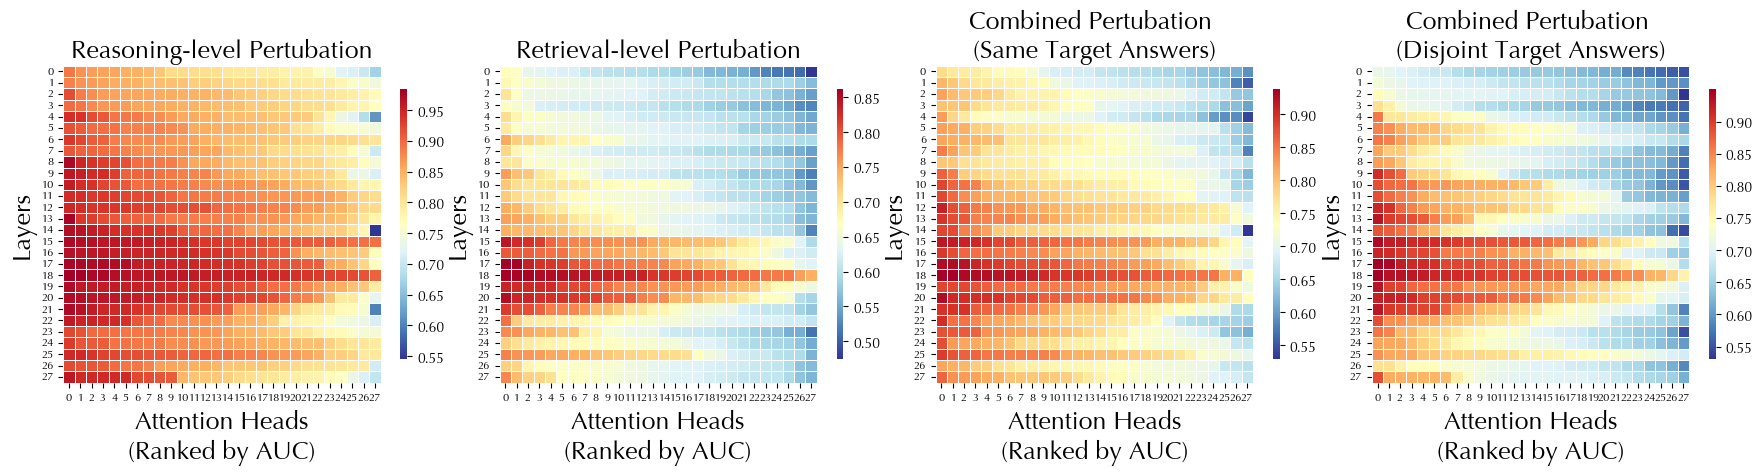

In [105]:
fig_all, axes = plt.subplots(1, 4, figsize=(22, 5))
fig_all.subplots_adjust(wspace=0.1, hspace=0.1)  # wspace是宽度间距，
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1qwen"
GROUP_NAME = "SciEng"
MODEL_LABEL = "R1-Qwen-7B"
GROUP_LABEL = "SciEng"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation \n(Same Target Answers)", "Combined Pertubation \n(Disjoint Target Answers)"]
for idx, (SAVE_DIR, TITLE) in enumerate(zip(SAVE_DIRS, TITLES)):
    draw_attention_map_ax(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE, axes[idx])
path = f"output/{SHORT_MODEL_NAME}_{GROUP_NAME}_atten_map_all.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

auc_matrix_filtered shape: (32, 32)
auc_matrix_filtered shape: (32, 32)
auc_matrix_filtered shape: (32, 32)
auc_matrix_filtered shape: (32, 32)


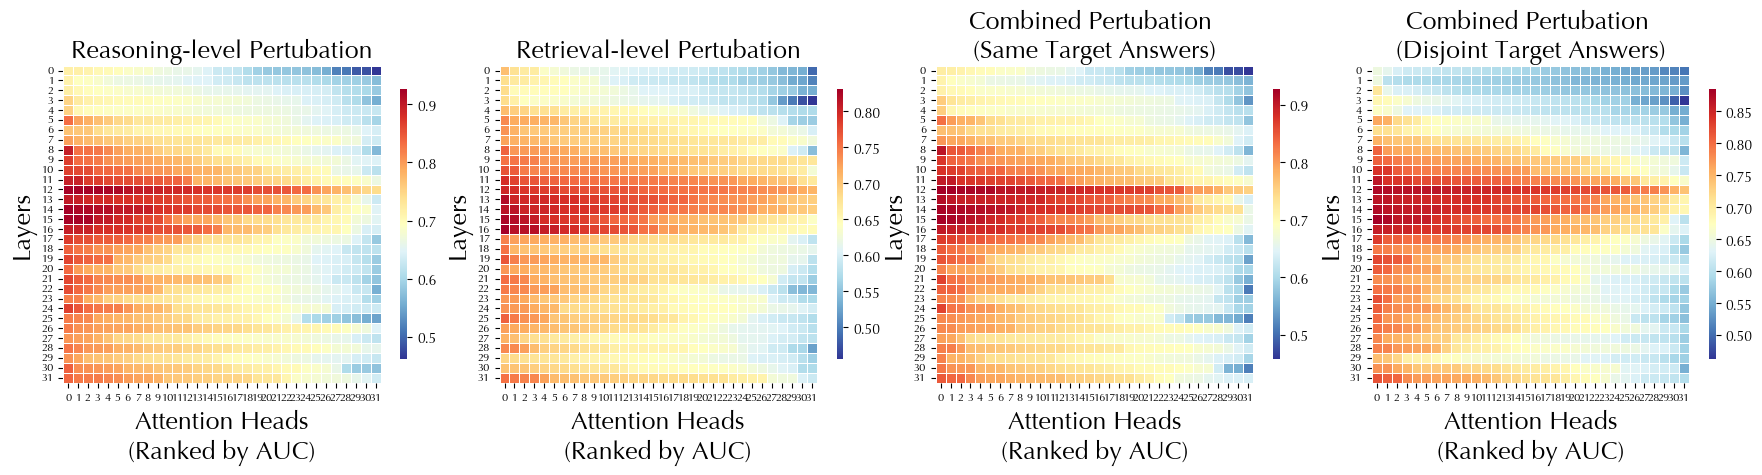

In [106]:
fig_all, axes = plt.subplots(1, 4, figsize=(22, 5))
fig_all.subplots_adjust(wspace=0.1, hspace=0.1)  # wspace是宽度间距，
SAVE_DIR_ROOT = "/data/yuhui/8/memory-perturb"
SAVE_DIRS = [f"{SAVE_DIR_ROOT}/atten_map_cot", f"{SAVE_DIR_ROOT}/atten_map_memory", f"{SAVE_DIR_ROOT}/atten_map_same", f"{SAVE_DIR_ROOT}/atten_map", ]
SHORT_MODEL_NAME = "r1llama"
GROUP_NAME = "MathLogic"
MODEL_LABEL = "R1-Llama-8B"
GROUP_LABEL = "Math&Logic"
TITLES = ["Reasoning-level Pertubation", "Retrieval-level Pertubation", "Combined Pertubation \n(Same Target Answers)", "Combined Pertubation \n(Disjoint Target Answers)"]
for idx, (SAVE_DIR, TITLE) in enumerate(zip(SAVE_DIRS, TITLES)):
    draw_attention_map_ax(SAVE_DIR, SHORT_MODEL_NAME, GROUP_NAME, MODEL_LABEL, GROUP_LABEL, TITLE, axes[idx])
path = f"output/{SHORT_MODEL_NAME}_{GROUP_NAME}_atten_map_all.pdf"
fig_all.savefig(path, dpi=300, bbox_inches = "tight", pad_inches=0)

In [72]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as patches
# from matplotlib.colors import LinearSegmentedColormap
# import seaborn as sns

# SAVE_DIR = "/data/yuhui/8/memory-perturb/atten_map"
# SHORT_MODEL_NAME = "r1llama"
# GROUP_NAME = "MathLogic"

# # load the auc_matrix_filtered
# auc_matrix_filtered = np.load(f'{SAVE_DIR}/{SHORT_MODEL_NAME}_{GROUP_NAME}_auc_matrix_filtered.npy')
# print(f"auc_matrix_filtered shape: {auc_matrix_filtered.shape}")

# # load the atteniton map
# items = np.load(f'{SAVE_DIR}/{SHORT_MODEL_NAME}_{GROUP_NAME}_layer_head_atten_map.npz')
# items = [np.array(items[f'item_{i}']) for i in range(len(items.files))]
# print(f"items shape: {items[0].shape}")

# # load the labels
# labels = np.load(f'{SAVE_DIR}/{SHORT_MODEL_NAME}_{GROUP_NAME}_labels.npy')
# print(f"labels shape: {labels.shape}")

# top_heads = [(auc_matrix_filtered[i,j],i,j) for i in range(auc_matrix_filtered.shape[0]) for j in range(auc_matrix_filtered.shape[1])]

# top_heads = sorted(top_heads, key=lambda x: x[0], reverse=True)

# # top_one_index = (top_heads[0][1], top_heads[0][2])


In [73]:
# samples_per_label = 10
# # get 10 samples for label 0
# label_0_samples = np.where(labels == 0)[0]
# label_0_samples = label_0_samples[:samples_per_label]


# # get 10 samples for label 1
# label_1_samples = np.where(labels == 1)[0]
# label_1_samples = label_1_samples[:samples_per_label]



# # get 10 samples for label 0
# label_2_samples = np.where(labels == 2)[0]
# label_2_samples = label_2_samples[:samples_per_label]

# print(label_0_samples)
# print(label_1_samples)
# print(label_2_samples)

In [74]:
# def to_image(items, sample_idx, top_index):
#     size = items[sample_idx].shape[-1]
#     # matrix = items[sample_idx][top_index[0]][top_index[1]][20: (size // 20 - 1) * 20]
#     matrix = items[sample_idx][top_index[0]][top_index[1]][size % 20:]
#     # matrix = items[sample_idx][top_index[0]][top_index[1]][:size // 20 * 20]
#     # min_max normalize
#     # matrix = (matrix - matrix.min()) / (matrix.max() - matrix.min())
#     matrix = matrix / sum(matrix)
#     matrix = matrix.reshape(20, -1)
#     return matrix

# # def draw_heatmap(items, sample_idx, top_index):
# #     matrix = to_image(items, sample_idx, top_index)
# #     plt.imshow(matrix)

In [75]:
# # answer 位置的token
# sample_idx0, sample_idx1, sample_idx2 = 0, 3, 12
# top_index = 0
# top_one_index = top_heads[top_index][1], top_heads[top_index][2]
# plt.figure(figsize=(10, 30))
# plt.subplot(3,1,1)
# # draw heatmap
# plt.imshow(to_image(items, sample_idx0, top_one_index))

# plt.subplot(3,1,2)
# # size2 = items[sample_idx1].shape[-1]
# # plt.imshow(items[sample_idx1][top_one_index[0]][top_one_index[0]][:size2 // 20 * 20].reshape(20, -1) / sum(items[sample_idx1][top_one_index[0]][top_one_index[0]][:size2 // 20 * 20].reshape(20, -1)))
# plt.imshow(to_image(items, sample_idx1, top_one_index))
# plt.subplot(3,1,3)
# # size3 = items[sample_idx2].shape[-1]
# # plt.imshow(items[sample_idx2][top_one_index[0]][top_one_index[0]][:size3 // 20 * 20].reshape(20, -1) / sum(items[sample_idx2][top_one_index[0]][top_one_index[0]][:size3 // 20 * 20].reshape(20, -1)))
# # plt.imshow(items[sample_idx2][top_one_index[0]][top_one_index[0]][ size3 % 20:].reshape(20, -1) )
# plt.imshow(to_image(items, sample_idx2, top_one_index))
# plt.show()